# **Experiment Notebook**



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


In [ ]:
student_name = 'Sonal Rao'

In [ ]:
student_id = '25533441'

In [ ]:
experiment_id = '0'

In [ ]:
business_objective = 'To accurately predict customer churn to enhance retention strategies, optimize marketing efforts, and ultimately increase revenue and customer lifetime value.'

<hr>

## B. Experiment Description


In [ ]:
experiment_hypothesis = 'There is no specific hypothesis being tested at this stage. The focus was on exploratory data analysis (EDA) and preparing the dataset for upcoming experiments. Key steps included examining the data, identifying patterns, and addressing issues such as missing values and class imbalance to ensure the dataset is ready for further analysis.'

In [ ]:
experiment_expectations = 'The objective is to evaluate the baseline performance of the project while addressing key data quality issues that may affect model performance. This involves identifying and resolving any data inconsistencies or gaps that could impact the effectiveness of the models.'

<hr>

## C. Data Understanding


In [ ]:
data_understanding_executive_summary = 'The dataset contains 34,586 entries and 31 features, encompassing customer demographics, service usage patterns, and subscription details. Approximately 17.8% of the customers have churned. Key variables such as MonthlyCharges, ViewingHoursPerWeek, and GenrePreference are crucial for predicting churn. However, challenges such as missing data in fields like Postcode and the class imbalance between churned and non-churned customers need to be addressed for accurate predictions.'

### C.0 Import Packages

In [ ]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Altair for plotting
import altair as alt

# Numpy for data manipulation
import numpy as np

#summary tools for enhanced EDA
!pip install summarytools
from summarytools import dfSummary
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

  Using cached jedi-0.19.1-py2.py3-none-any.whl.metadata (22 kB)
Using cached jedi-0.19.1-py2.py3-none-any.whl (1.6 MB)


<hr>

### C.1   Load Datasets

In [ ]:
# Load data
# Do not change this code

df0 = pd.read_csv("subscription_data_0.csv")
df1 = pd.read_csv("subscription_data_1.csv")
df2 = pd.read_csv("subscription_data_2.csv")
df3 = pd.read_csv("subscription_data_3.csv")
df4 = pd.read_csv("subscription_data_4.csv")
df5 = pd.read_csv("subscription_data_5.csv")
df6 = pd.read_csv("subscription_data_6.csv")
df7 = pd.read_csv("subscription_data_7.csv")
df8 = pd.read_csv("subscription_data_8.csv")
df9 = pd.read_csv("subscription_data_9.csv")

In [ ]:
#Exploring df0

df0

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12185,Jennifer,Bennett,2970,Martinez Isle,Drives,Bethanyfort,25844.0,MT,NaN,11,...,Action,2.557163,4,Female,3,Yes,Yes,EJQSZBW6E5,0,0-4-25844.0
12186,Amber,Wang,94352,Murphy Harbors,Flat,Rachelhaven,13733.0,FM,NaN,37,...,Sci-Fi,1.108598,2,Female,21,No,No,2QCXDDLCA0,0,0-4-13733.0
12187,Kimberly,Johnson,3917,Bryan Drive,Oval,South Patricia,88670.0,IL,NaN,12,...,Sci-Fi,3.836587,4,Male,0,No,No,LDYUJH7NYQ,1,1-4-88670.0
12188,Nicholas,Thomas,2888,Jennifer Mission,Stream,Lake Thomas,25720.0,OR,NaN,119,...,Sci-Fi,1.730010,2,Male,5,Yes,Yes,2YLQD4OOY2,0,1-4-25720.0


> Insights: df0 has 12190 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df1
df1

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Catherine,George,41355,Zachary Village,Well,Stephanieburgh,19353.0,AZ,white,89,...,Fantasy,2.595064,7,Female,10,No,Yes,342DFV3G9S,1,0-3-19353.0
1,Antonio,Rollins,79884,Thomas Road,Extensions,North Gavin,78854.0,GA,white,24,...,Fantasy,4.914141,1,Male,10,No,Yes,PF9S769KTG,0,1-3-78854.0
2,Brandy,Vargas,884,Hunter Villages,Summit,Monteston,78343.0,HI,hispanic,44,...,Comedy,2.458039,8,Female,8,Yes,Yes,XNVGSE0O85,1,0-2-78343.0
3,Feargal,Giles,799,Julie Point,Turnpike,APO AE 57284,NaN,NaN,white,34,...,Sci-Fi,2.664434,1,Male,5,No,No,0B0Z6PX7EO,1,1-3-nan
4,Jillian,Martin,282,Frederick Fort,Meadow,Lake Kimberly,19968.0,NJ,white,33,...,Comedy,4.345574,5,Male,0,Yes,No,CPK8B7E3RR,0,1-3-19968.0


> Insights: df1 has 5 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df2
df2

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Samuel,Oliver,5021,Shelton Causeway,Viaduct,Mackborough,72166.0,MO,white,15,...,Comedy,3.170629,6,Female,1,No,No,X2HGS4ADSL,0,0-3-72166.0
1,Victoria,Taylor,6903,Eric Ford,Expressway,Barrontown,71754.0,MO,white,92,...,Sci-Fi,4.859899,3,Female,10,No,No,BS9SPB0STR,0,0-3-71754.0
2,Mr,Tom,46121,Gonzales Plains,Plain,Nancyfurt,65573.0,CO,asian,33,...,Sci-Fi,1.189857,1,Female,23,Yes,No,YBORF9BXUU,0,0-0-65573.0
3,Joanna,Price,442,Joan Vista,Crescent,South Joyce,56105.0,IL,white,90,...,Comedy,1.577972,3,Female,11,No,No,RVYUS3NCYP,0,0-3-56105.0
4,Alana,Doolan,9501,Jessica Shores,Islands,Amandachester,87247.0,FM,white,113,...,Sci-Fi,3.405001,4,Male,24,Yes,Yes,LA8VABTNIT,0,1-3-87247.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2764,Marcus,Holder,43862,Cynthia Path,Mission,Lake Sheena,95735.0,FM,NaN,61,...,Comedy,1.422614,0,Male,18,No,No,Z0CF8FOL66,0,1-4-95735.0
2765,Matilda,Valentino,197,Thomas Inlet,Bridge,Kleinton,18736.0,FL,NaN,29,...,Action,4.132443,6,Male,24,No,No,5LBNNOLOQA,0,1-4-18736.0
2766,Ayesha,Chauhan,4032,Neal Walk,Land,DPO AE 09693,NaN,NaN,NaN,70,...,Fantasy,2.281081,4,Female,7,No,No,BODNCE425D,0,0-4-nan
2767,Sofía,Trejo,9126,Leonard Alley,Trafficway,North Monica,74001.0,FL,NaN,78,...,Fantasy,4.593817,0,Male,5,No,Yes,YTMORT59YL,1,1-4-74001.0


> Insights: df2 has 2769 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df3
df3

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Lori,Jarvis,846,Alan Meadows,Lane,FPO AE 78469,NaN,NaN,white,11,...,Drama,3.075018,0,Female,17,No,No,KEQ4VEG2FJ,0,0-3-nan
1,Dr,Colin,45125,Little Terrace,River,North Jenniferton,4128.0,ID,white,22,...,Action,2.806335,5,Female,24,Yes,No,LL3XRMABSB,0,0-3-4128.0
2,David,Perez,31258,Robert Shoals,Islands,Thomasberg,67735.0,WY,hispanic,4,...,Drama,2.467155,1,Female,11,Yes,Yes,5ZG93RBWOD,0,0-2-67735.0
3,Allison,Baldwin,743,Nichols Summit,Throughway,Port Emma,40097.0,MS,white,74,...,Comedy,2.402098,9,Female,18,No,Yes,3J4ZFIXKJR,1,0-3-40097.0
4,Tammy,Martinez,495,Lindsey Freeway,Branch,East Douglasfort,24108.0,WA,hispanic,114,...,Drama,3.669507,0,Female,10,Yes,Yes,DRSOGC6UB2,1,0-2-24108.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2788,Taran,Chowdhury,714,Greene Isle,Views,Russellmouth,64333.0,FL,NaN,18,...,Fantasy,2.698020,4,Male,1,No,No,6FIBT0PIUZ,0,1-4-64333.0
2789,Dr.,Kealan,15637,Brown Locks,Junction,FPO AE 45889,NaN,NaN,NaN,63,...,Drama,1.319616,0,Male,23,No,No,AFOU6ECBH7,0,1-4-nan
2790,Reina,Armando,8059,Collins Common,Road,Gibsonland,38058.0,KY,NaN,47,...,Drama,1.402909,4,Female,17,No,Yes,8QAH9OABHL,1,0-4-38058.0
2791,Corey,Duff,39070,Lindsey Hollow,Well,Padillastad,53977.0,WV,NaN,74,...,Fantasy,4.589844,0,Female,22,No,Yes,ZB1IXR3K2Y,0,0-4-53977.0


> Insights: df0 has 2793 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df4
df4

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Anel,Estrada,4338,Julia Passage,Fords,West Maria,11702.0,DE,hispanic,47,...,Action,2.426359,3,Male,10,No,Yes,TQ839ANJNY,0,1-2-11702.0
1,Tiffany,Davis,61183,Huynh Valleys,Meadows,East Kyle,24902.0,TN,white,17,...,Sci-Fi,2.488114,5,Female,21,No,No,BEHRE4ADRB,0,0-3-24902.0
2,Mark,Wolfe,557,Anderson Streets,Route,Port Veronica,30365.0,MH,white,102,...,Sci-Fi,3.336710,5,Male,24,No,Yes,9J2WF0F2JA,0,1-3-30365.0
3,Olivia,Smith-Webb,88361,Beverly Park,Manors,East Matthewside,37495.0,CA,white,8,...,Drama,3.062146,9,Female,1,No,No,3FJE6IKMR6,0,0-3-37495.0
4,Kelly,Parker,91997,Davis Oval,Trail,Port George,28994.0,VA,white,87,...,Drama,1.027004,1,Male,22,Yes,Yes,NODJVM52VF,0,1-3-28994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2789,Owen,Webb-Hall,9555,Tanner Crescent,Manor,Kleinmouth,80406.0,LA,NaN,116,...,Sci-Fi,2.706995,4,Male,13,Yes,Yes,CID49ZBKDV,0,1-4-80406.0
2790,Dulce,Mariana,2308,Keith Path,Falls,New Jeffreyberg,57722.0,WV,NaN,8,...,Fantasy,4.593740,4,Male,18,Yes,No,G5JJSA8FZC,1,1-4-57722.0
2791,Colin,Collier-Russell,367,Sanchez Dale,Wall,Albertchester,34734.0,VA,NaN,34,...,Fantasy,1.801052,3,Male,20,Yes,No,TMEUZH71N3,0,1-4-34734.0
2792,Dr,Max,1951,Brown Gateway,Forks,North Scottfort,50085.0,IA,NaN,18,...,Action,2.877378,8,Female,8,No,Yes,OV4G17PDA6,1,0-4-50085.0


> Insights: df4 has 2794 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df5
df5

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Dr,Joanne,78407,Robert Port,Prairie,Trujilloton,53745.0,MH,white,24,...,Fantasy,2.726895,6,Male,16,No,No,AOUOY4IW12,0,1-3-53745.0
1,Kevin,Ross,1422,Hernandez Track,Springs,Hernandezland,86174.0,LA,white,21,...,Drama,3.705761,7,Male,10,No,No,QNJ2RK63VQ,0,1-3-86174.0
2,Anthony,Ortiz,112,Charles Mount,Pine,North Robert,25538.0,PW,hispanic,37,...,Fantasy,4.821065,5,Female,0,Yes,Yes,X5V2QRLEM7,0,0-2-25538.0
3,Michèle,Veilleux,2510,Melton Courts,Divide,Hallburgh,53299.0,MA,white,28,...,Sci-Fi,3.552793,4,Male,13,Yes,Yes,RNADD4EFY4,1,1-3-53299.0
4,Alexander,Maddox,956,Hall Ports,Tunnel,APO AP 99767,NaN,NaN,white,71,...,Comedy,4.010169,7,Male,0,Yes,No,1ZZPS6K42I,0,1-3-nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2811,Dean,Maccarthy,811,Smith Walks,Drives,Kimberlyborough,74728.0,SD,NaN,114,...,Comedy,1.932391,5,Female,17,No,No,RPQ5OSDOAW,0,0-4-74728.0
2812,Laurie,Connaughton-Bolger,63901,Jones Pine,Shore,Port Derekborough,23560.0,NE,NaN,10,...,Action,2.837177,5,Female,5,No,Yes,SX4SYY9UIY,0,0-4-23560.0
2813,Mrs,Rachael,796,Elizabeth Junctions,Alley,FPO AP 84828,NaN,NaN,NaN,51,...,Action,1.920531,6,Female,9,No,Yes,RG368NSBQQ,0,0-4-nan
2814,Christine,Arthurs,76016,Desiree Loop,Center,Hamiltonburgh,72003.0,KS,NaN,104,...,Drama,4.590896,7,Male,4,Yes,No,9SCPGPR8O6,0,1-4-72003.0


> Insights: df5 has 2816 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df6
df6

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Erika,Williams,5143,Sanchez Mountain,Inlet,South Renee,22837.0,SD,black,118,...,Sci-Fi,2.455370,6,Male,15,No,Yes,WA0OMI1BSD,0,1-1-22837.0
1,Kim,Long,24429,Joshua Loaf,Expressway,Jessetown,41712.0,NH,white,95,...,Drama,4.682225,9,Female,17,Yes,Yes,PQEK3ZRD14,0,0-3-41712.0
2,Lee,Winter,53004,Curtis Tunnel,Isle,Matthewmouth,55827.0,AS,white,80,...,Drama,1.868602,2,Male,4,No,No,MZ7PMZCSQL,0,1-3-55827.0
3,Imelda,Tarantino-Aloisio,6730,Matthew River,Shore,North Staciechester,70116.0,MA,white,111,...,Sci-Fi,3.458868,6,Female,12,Yes,Yes,WCSKRZ1N4H,0,0-3-70116.0
4,Samantha,Wells,138,Barbara Islands,Alley,Alejandraland,6247.0,VA,white,80,...,Fantasy,2.393086,6,Male,19,Yes,No,ECVYE0COK9,0,1-3-6247.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,Mx.,Christina,9795,Jackson Shore,Tunnel,Hunterstad,55421.0,KS,NaN,100,...,Drama,4.020993,7,Female,19,No,No,9L82AM0YAD,0,0-4-55421.0
2796,Patrick,Gould-Skinner,1650,Flores Mills,Brooks,Kevinhaven,31764.0,KY,NaN,27,...,Comedy,3.567039,7,Female,0,No,No,4EP3BF78BG,1,0-4-31764.0
2797,Aarush,Yadav,925,Moore Prairie,Trail,Shelleyland,31213.0,ME,NaN,35,...,Sci-Fi,4.060511,6,Female,15,No,No,X4KSJ27APO,0,0-4-31213.0
2798,Sig.ra,Renata,3901,Smith Lights,Squares,Lake Vanessachester,23440.0,AR,NaN,67,...,Sci-Fi,4.332248,5,Female,2,No,Yes,2JDZNAWJ7J,1,0-4-23440.0


> Insights: df6 has 2800 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df7
df7

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Jasmine,Howell,190,Oneal Port,Landing,Lake Matthewview,44495.0,UT,white,4,...,Comedy,1.703936,1,Female,10,Yes,No,A0H9DEUMSC,0,0-3-44495.0
1,Anna,Cook,57,Ryan Island,Drives,Melissaton,7533.0,GU,white,12,...,Comedy,2.731431,5,Female,10,No,Yes,2TYSL7W612,1,0-3-7533.0
2,Katrina,Chang,4639,Stephenson Mills,Shoals,APO AA 34814,NaN,NaN,asian,45,...,Action,2.300513,3,Female,22,Yes,No,LSHZP65UMV,0,0-0-nan
3,Mr.,Zachary,6838,John Station,Causeway,Port Tyler,21488.0,MN,white,102,...,Action,1.546935,9,Male,11,No,No,MJCN1QCTFO,0,1-3-21488.0
4,Heather,Young,12938,Melissa Tunnel,Circles,North Shaunview,6840.0,OK,white,15,...,Fantasy,1.896405,9,Male,3,No,Yes,SX8GYAVL1F,0,1-3-6840.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2780,Ayesha,Walia,4619,Karen Knoll,Mission,Austinshire,20681.0,OK,NaN,49,...,Drama,3.472866,4,Female,17,No,Yes,IXAD1WK1E8,1,0-4-20681.0
2781,Mrs,Donna,2770,Robert Islands,Radial,Maryview,92225.0,AS,NaN,109,...,Drama,4.687383,8,Male,13,No,No,8OXALNZE4Y,1,1-4-92225.0
2782,Eloisa,Barbara,9179,Amanda Lodge,Square,Gabrielleton,88638.0,OH,NaN,30,...,Action,1.095262,3,Male,20,Yes,Yes,9IL84M2ES1,0,1-4-88638.0
2783,Roy,Connor,156,Blackburn Ranch,Rapid,Victorview,63706.0,PR,NaN,112,...,Fantasy,4.174782,6,Male,0,No,Yes,GTCH8IUDZW,0,1-4-63706.0


> Insights: df7 has 2785 rows and 31 columns which can be used to analyse the data

In [ ]:
#Exploring df8
df8

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Jesse,Mcintyre,223,Conrad Summit,Flat,East Darlene,29112.0,WY,white,107,...,Comedy,2.901723,7,Female,5,No,No,8LJ2E9ADDH,0,0-3-29112.0
1,Dr.,Todd,5249,Taylor Harbors,Islands,Lisaville,77540.0,ID,white,80,...,Action,4.620689,6,Male,15,No,Yes,U794G44B8D,1,1-3-77540.0
2,Pamela,Luna,2240,John Overpass,Oval,Jessicaside,87363.0,MS,hispanic,11,...,Comedy,2.632730,9,Female,16,No,Yes,2VAIR4ROVX,0,0-2-87363.0
3,Christopher,Day,966,Carla Isle,Keys,Wilsonborough,12497.0,NH,white,109,...,Action,3.273230,8,Female,1,Yes,Yes,F6L2M7MPQF,0,0-3-12497.0
4,Eamonn,Rea,340,Kim Summit,Stravenue,East Alexandriabury,57052.0,VT,white,52,...,Fantasy,1.365186,7,Male,8,Yes,Yes,FATDM2TF32,0,1-3-57052.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,Kimaya,Sankar,63693,Bauer Drive,Landing,Hollowayburgh,39580.0,FL,NaN,59,...,Sci-Fi,1.845540,9,Female,0,No,No,XWXE23IUPE,0,0-4-39580.0
2846,Natasha,Meenan,21524,Connor Square,Club,Smithberg,25360.0,AR,NaN,10,...,Comedy,3.379149,4,Female,20,Yes,No,7PL1G3L2BA,0,0-4-25360.0
2847,Olivier,Proulx,6916,Travis Ford,Prairie,Ashleyfort,57139.0,WA,NaN,4,...,Action,4.226855,0,Male,23,Yes,Yes,W6UEW3R8PF,1,1-4-57139.0
2848,Jerónimo,Villalpando,1261,Jacob Oval,Courts,West Steven,51487.0,MA,NaN,2,...,Action,4.740167,8,Female,4,No,No,4THIFI0PLK,0,0-4-51487.0


> Insights: df8 has 2850 rows and 31 columns

In [ ]:
#Exploring df9
df9

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Carolyn,Barnes,624,Joann Ridge,Hills,South Michelleton,75244.0,MD,white,49,...,Drama,2.156288,1,Male,6,Yes,No,ZZK5TMZGUK,0,1-3-75244.0
1,Lisa,Garcia,790,Joshua Unions,Walks,Lake Lauren,63949.0,CO,hispanic,17,...,Fantasy,2.874365,9,Male,4,No,No,YMHIEO2K54,0,1-2-63949.0
2,Hugh,Harrison,254,Alex Harbor,Fort,Gordonland,52236.0,FM,white,117,...,Comedy,2.300348,5,Female,5,No,Yes,5PGIGKGLAJ,0,0-3-52236.0
3,Rebecca,Edwards,14851,Rodriguez Dale,Village,East Nicholas,8980.0,WI,white,95,...,Action,3.491410,8,Male,24,Yes,No,D5GO9V5SZT,0,1-3-8980.0
4,Tricia,Salazar,321,Brown Valleys,Squares,South Sarahmouth,66421.0,MN,hispanic,14,...,Comedy,3.592129,9,Male,5,Yes,No,DVH3VTVHY1,1,1-2-66421.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2779,Lic.,Ilse,14356,Contreras Landing,Highway,APO AA 79140,NaN,NaN,white,113,...,Fantasy,2.571882,5,Male,3,No,No,BSQ3ZN2AV1,0,1-3-nan
2780,Dr,Joanna,605,Taylor River,Mews,South Kaitlynport,95400.0,AR,white,42,...,Drama,2.361023,6,Male,17,No,No,B8BLN9K629,1,1-3-95400.0
2781,Giorgio,Bajardi-Battelli,179,James Extensions,Radial,APO AE 13486,NaN,NaN,white,43,...,Action,3.695672,5,Male,6,No,No,B01577YHQO,0,1-3-nan
2782,Miss,June,762,Kyle Landing,Shore,Lake Johnbury,36487.0,MA,NaN,110,...,Fantasy,4.892557,1,Male,5,No,No,H8OZZRCV21,0,1-4-36487.0


> Insights: df9 has 2784 rows and 31 columns which can be used to analyse the data

In [ ]:
dfs = [df0, df1, df2, df3, df4, df5, df6, df7, df8, df9]

# Concatenating only the 'CustomerID' columns
customer_ids = pd.concat([df['CustomerID'] for df in dfs], ignore_index=True)

# Finding duplicates in the customer IDs
duplicates = customer_ids[customer_ids.duplicated()]

# Printing the duplicate customer IDs
if not duplicates.empty:
    print(f"Found {len(duplicates)} duplicate CustomerIDs: \n", duplicates)
else:
    print("No duplicate CustomerIDs found across datasets.")

No duplicate CustomerIDs found across datasets.


 Combining Datasets for better analysis, as no duplicates are found.

In [ ]:
df_list = [pd.read_csv(f"subscription_data_{i}.csv") for i in range(10)]
df = pd.concat(df_list, ignore_index=True)

In [ ]:
df.to_csv('combined_dataset.csv', index=False)
df_combined = pd.read_csv('combined_dataset.csv')

<hr>

### C.2 Explore Datasets

Analysing to do a custom split for training, testing, and validation.

In [ ]:
df

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,20,...,Sci-Fi,2.176498,4,Male,3,No,No,CB6SXPNVZA,0,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,NaN,NaN,white,57,...,Action,3.478632,8,Male,23,No,Yes,S7R2G87O09,0,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,73,...,Fantasy,4.238824,6,Male,1,Yes,Yes,EASDC20BDT,0,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,32,...,Drama,4.276013,2,Male,24,Yes,Yes,NPF69NT69N,0,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,57,...,Comedy,3.616170,4,Female,0,No,No,4LGYPK7VOL,0,0-3-99324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34581,Lic.,Ilse,14356,Contreras Landing,Highway,APO AA 79140,NaN,NaN,white,113,...,Fantasy,2.571882,5,Male,3,No,No,BSQ3ZN2AV1,0,1-3-nan
34582,Dr,Joanna,605,Taylor River,Mews,South Kaitlynport,95400.0,AR,white,42,...,Drama,2.361023,6,Male,17,No,No,B8BLN9K629,1,1-3-95400.0
34583,Giorgio,Bajardi-Battelli,179,James Extensions,Radial,APO AE 13486,NaN,NaN,white,43,...,Action,3.695672,5,Male,6,No,No,B01577YHQO,0,1-3-nan
34584,Miss,June,762,Kyle Landing,Shore,Lake Johnbury,36487.0,MA,NaN,110,...,Fantasy,4.892557,1,Male,5,No,No,H8OZZRCV21,0,1-4-36487.0


In [ ]:
# Check for duplicates
duplicates = df.duplicated()

# Print number of duplicates
print(f"Number of duplicates: {duplicates.sum()}")

Number of duplicates: 0


There are no duplicates in the combined pdf

In [ ]:
df.describe()

,BuildingNumber,Postcode,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,34586.000000,30802.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.000000,34586.00000,34586.000000,34586.000000
mean,18382.107384,50439.623498,60.034205,12.481594,749.126439,20.575998,92.427566,24.615972,3.009000,4.49893,12.020210,0.177528
std,27820.825292,28715.400686,34.356975,4.303706,523.014579,11.233775,50.592829,14.450537,1.154705,2.87045,7.191615,0.382121
min,0.000000,501.000000,1.000000,4.990062,5.101684,1.000133,5.002643,0.000000,1.000007,0.00000,0.000000,0.000000
25%,670.000000,25490.250000,30.000000,8.744131,330.732530,10.876132,48.448066,12.000000,2.007270,2.00000,6.000000,0.000000
50%,4495.000000,50572.000000,60.000000,12.472481,644.610183,20.666960,92.674569,25.000000,3.021349,4.00000,12.000000,0.000000
75%,24926.750000,75218.500000,90.000000,16.174570,1087.452915,30.302291,136.051872,37.000000,4.007800,7.00000,18.000000,0.000000
max,99999.000000,99947.000000,119.000000,19.989412,2373.700290,39.998560,179.999025,49.000000,4.999845,9.00000,24.000000,1.000000


In [ ]:
df.tail()

,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,AccountAge,...,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn,Cohort
34581,Lic.,Ilse,14356,Contreras Landing,Highway,APO AA 79140,NaN,NaN,white,113,...,Fantasy,2.571882,5,Male,3,No,No,BSQ3ZN2AV1,0,1-3-nan
34582,Dr,Joanna,605,Taylor River,Mews,South Kaitlynport,95400.0,AR,white,42,...,Drama,2.361023,6,Male,17,No,No,B8BLN9K629,1,1-3-95400.0
34583,Giorgio,Bajardi-Battelli,179,James Extensions,Radial,APO AE 13486,NaN,NaN,white,43,...,Action,3.695672,5,Male,6,No,No,B01577YHQO,0,1-3-nan
34584,Miss,June,762,Kyle Landing,Shore,Lake Johnbury,36487.0,MA,NaN,110,...,Fantasy,4.892557,1,Male,5,No,No,H8OZZRCV21,0,1-4-36487.0
34585,Olga,Ferrante-Foletti,934,Powell Roads,Circles,East Samanthastad,29779.0,DC,NaN,67,...,Fantasy,1.876308,4,Male,19,No,Yes,Q50L9LD31C,1,1-4-29779.0


In [ ]:
df.shape

(34586, 31)

In [ ]:
# Check for column data types and missing values
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   FirstName                 34586 non-null  object 
 1   LastName                  34583 non-null  object 
 2   BuildingNumber            34586 non-null  int64  
 3   StreetName                34586 non-null  object 
 4   StreetType                34586 non-null  object 
 5   City                      34586 non-null  object 
 6   Postcode                  30802 non-null  float64
 7   State                     30802 non-null  object 
 8   Ethnicity                 23536 non-null  object 
 9   AccountAge                34586 non-null  int64  
 10  MonthlyCharges            34586 non-null  float64
 11  TotalCharges              34586 non-null  float64
 12  SubscriptionType          34586 non-null  object 
 13  PaymentMethod             34586 non-null  object 
 14  Paperl

> Insights: Merged the datasets and analysed it to get better understanding

> Considerations: Identified the outliers and insights using descriptive statistics

> Issues found: The need of removing outliers and missing data

<hr>

### C.3 Explore Target variable

In [ ]:
# Set the name of the target column
target_name = 'Churn'

In [ ]:
# describing the target column
df[target_name].describe()

,Churn
count,34586.000000
mean,0.177528
std,0.382121
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
# Checking for missing values in df
df.isnull().sum()

,0
FirstName,0
LastName,3
BuildingNumber,0
StreetName,0
StreetType,0
City,0
Postcode,3784
State,3784
Ethnicity,11050
AccountAge,0


In [ ]:
# Filling missing values for 'LastName' with 'Unknown'
df['LastName'].fillna('Unknown', inplace=True)

# Filling missing values for 'Ethnicity' with the mode (most frequent value)
df['Ethnicity'].fillna(df['Ethnicity'].mode()[0], inplace=True)

# Filling missing values for 'State' with the mode
df['State'].fillna(df['State'].mode()[0], inplace=True)

# Filling missing values for 'Postcode' with the median
df['Postcode'].fillna(df['Postcode'].median(), inplace=True)

# Verify if missing values have been handled
print(df.isnull().sum())


FirstName                   0
LastName                    0
BuildingNumber              0
StreetName                  0
StreetType                  0
City                        0
Postcode                    0
State                       0
Ethnicity                   0
AccountAge                  0
MonthlyCharges              0
TotalCharges                0
SubscriptionType            0
PaymentMethod               0
PaperlessBilling            0
ContentType                 0
MultiDeviceAccess           0
DeviceRegistered            0
ViewingHoursPerWeek         0
AverageViewingDuration      0
ContentDownloadsPerMonth    0
GenrePreference             0
UserRating                  0
SupportTicketsPerMonth      0
Gender                      0
WatchlistSize               0
ParentalControl             0
SubtitlesEnabled            0
CustomerID                  0
Churn                       0
Cohort                      0
dtype: int64


In [ ]:
# Checking the value counts of the classes of 0 and 1
df['Churn'].value_counts()

,count
Churn,
0,28446
1,6140


<function matplotlib.pyplot.show(close=None, block=None)>

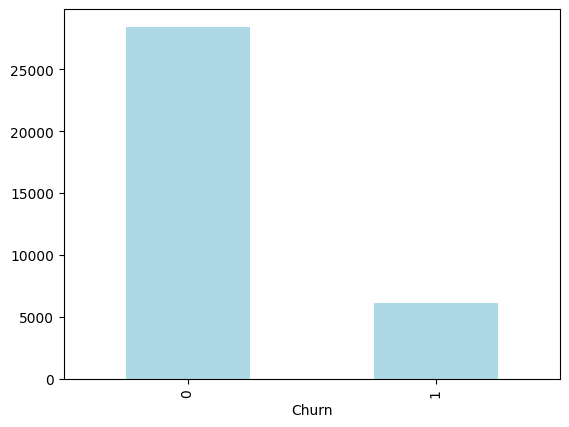

In [ ]:
# Checking the value counts of the classes of 0 and 1
df[target_name].value_counts().plot(kind='bar', color='LightBlue')
plt.show



Churn
0    82.247152
1    17.752848
Name: proportion, dtype: float64


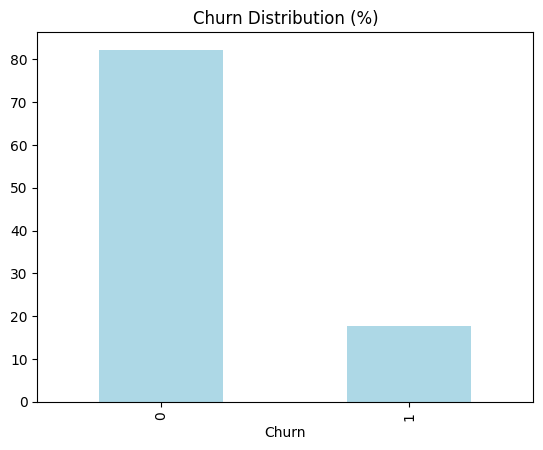

In [ ]:
# Calculating Churn Rate %
churn_distribution = df_combined['Churn'].value_counts(normalize=True) * 100
churn_distribution.plot(kind='bar', color='LightBlue',title='Churn Distribution (%)')
print(churn_distribution)

Insights: The churn dataset exhibits class imbalance, with 82.25% of the entries representing non-churn (0) and only 17.75% representing churn (1).

In [ ]:
# Understanding the categorical columns in the dataset
df_copy = df.copy()  # Create a copy of the original dataframe

# Select a few relevant categorical columns to check their content
df_copy[['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType',
         'City', 'Postcode', 'State', 'Ethnicity', 'SubscriptionType',
         'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
         'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl',
         'SubtitlesEnabled', 'Cohort']]


,FirstName,LastName,BuildingNumber,StreetName,StreetType,City,Postcode,State,Ethnicity,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,GenrePreference,Gender,ParentalControl,SubtitlesEnabled,Cohort
0,Aurora,Bravo,88588,Wanda Mission,Underpass,Sandyhaven,46890.0,NY,hispanic,Premium,Mailed check,No,Both,No,Mobile,Sci-Fi,Male,No,No,1-2-46890.0
1,Ana,María,69,Laura Gateway,Drive,DPO AA 59306,50572.0,MH,white,Basic,Credit card,Yes,Movies,No,Tablet,Action,Male,No,Yes,1-3-nan
2,Susan,Lambert,81311,Hunter Fort,Cove,South Sarahshire,12793.0,HI,white,Basic,Mailed check,Yes,Movies,No,Computer,Fantasy,Male,Yes,Yes,1-3-12793.0
3,David,Martinez,115,Whitney Drive,Valley,Danielside,56037.0,WV,hispanic,Basic,Electronic check,No,TV Shows,No,Tablet,Drama,Male,Yes,Yes,1-2-56037.0
4,Miss,Lydia,674,Stuart Ford,Trace,Johnsonland,99324.0,RI,white,Premium,Electronic check,Yes,TV Shows,No,TV,Comedy,Female,No,No,0-3-99324.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34581,Lic.,Ilse,14356,Contreras Landing,Highway,APO AA 79140,50572.0,MH,white,Basic,Credit card,No,TV Shows,Yes,Mobile,Fantasy,Male,No,No,1-3-nan
34582,Dr,Joanna,605,Taylor River,Mews,South Kaitlynport,95400.0,AR,white,Standard,Mailed check,Yes,Movies,No,Mobile,Drama,Male,No,No,1-3-95400.0
34583,Giorgio,Bajardi-Battelli,179,James Extensions,Radial,APO AE 13486,50572.0,MH,white,Premium,Credit card,No,TV Shows,No,Mobile,Action,Male,No,No,1-3-nan
34584,Miss,June,762,Kyle Landing,Shore,Lake Johnbury,36487.0,MA,white,Basic,Bank transfer,No,Both,Yes,Tablet,Fantasy,Male,No,No,1-4-36487.0


In [ ]:
# List of categorical columns to one-hot encode
categorical_columns = ['FirstName', 'LastName', 'BuildingNumber', 'StreetName', 'StreetType',
                       'City', 'Postcode', 'State', 'Ethnicity', 'SubscriptionType',
                       'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess',
                       'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl',
                       'SubtitlesEnabled', 'Cohort']

# Perform one-hot encoding using pandas get_dummies
df_copy = pd.get_dummies(df_copy, columns=categorical_columns, drop_first=True)

# Check the first few rows of the encoded dataframe
print(df_copy.head())

# Display the shape of the dataframe after encoding
print("Shape of the dataframe after one-hot encoding:", df_copy.shape)


   AccountAge  MonthlyCharges  TotalCharges  ViewingHoursPerWeek  \
0          20       11.055215    221.104302            36.758104   
1          57        5.175208    294.986882            32.450568   
2          73       12.106657    883.785952             7.395160   
3          32        7.263743    232.439774            27.960389   
4          57       16.953078    966.325422            20.083397   

   AverageViewingDuration  ContentDownloadsPerMonth  UserRating  \
0               63.531377                        10    2.176498   
1               25.725595                        18    3.478632   
2               57.364061                        23    4.238824   
3              131.537507                        30    4.276013   
4               45.356653                        20    3.616170   

   SupportTicketsPerMonth  WatchlistSize  CustomerID  ...  Cohort_1-4-99653.0  \
0                       4              3  CB6SXPNVZA  ...               False   
1                       8 

In [ ]:
# Identify non-numeric columns
non_numeric_columns = df_combined.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)
# Drop non-numeric columns for correlation calculation
numeric_df = df_combined.drop(columns=non_numeric_columns)

# Now, calculate correlation
correlation_matrix = numeric_df.corr()
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)
print(churn_correlation)

Non-numeric columns: Index(['FirstName', 'LastName', 'StreetName', 'StreetType', 'City', 'State',
       'Ethnicity', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling',
       'ContentType', 'MultiDeviceAccess', 'DeviceRegistered',
       'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled',
       'CustomerID', 'Cohort'],
      dtype='object')
Churn                       1.000000
MonthlyCharges              0.099633
SupportTicketsPerMonth      0.085398
WatchlistSize               0.028071
UserRating                  0.013111
Postcode                    0.002856
BuildingNumber             -0.004615
TotalCharges               -0.114946
ContentDownloadsPerMonth   -0.125693
ViewingHoursPerWeek        -0.137970
AverageViewingDuration     -0.146405
AccountAge                 -0.192684
Name: Churn, dtype: float64


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34586 entries, 0 to 34585
Columns: 135879 entries, AccountAge to Cohort_1-4-nan
dtypes: bool(135868), float64(5), int64(5), object(1)
memory usage: 4.4+ GB


Insights: Among the numerical columns, MonthlyCharges, WatchlistSize, and UserRating seem to be effective in correlation and can be used for model creation.

> Considerations: Focusing on categorical columns in the next section will be beneficial for gaining deeper insights into customer behavior and churn patterns. Analyzing these variables can uncover significant trends and relationships that may enhance our understanding of the factors driving customer retention and attrition.

> Issues found: Numerical columns have minimal impact on churn rates and may contribute to unnecessary complexity by adding features that do not significantly enhance the model's predictive power during training.

<hr>

### C.4 Explore Variables of Interest

<hr>

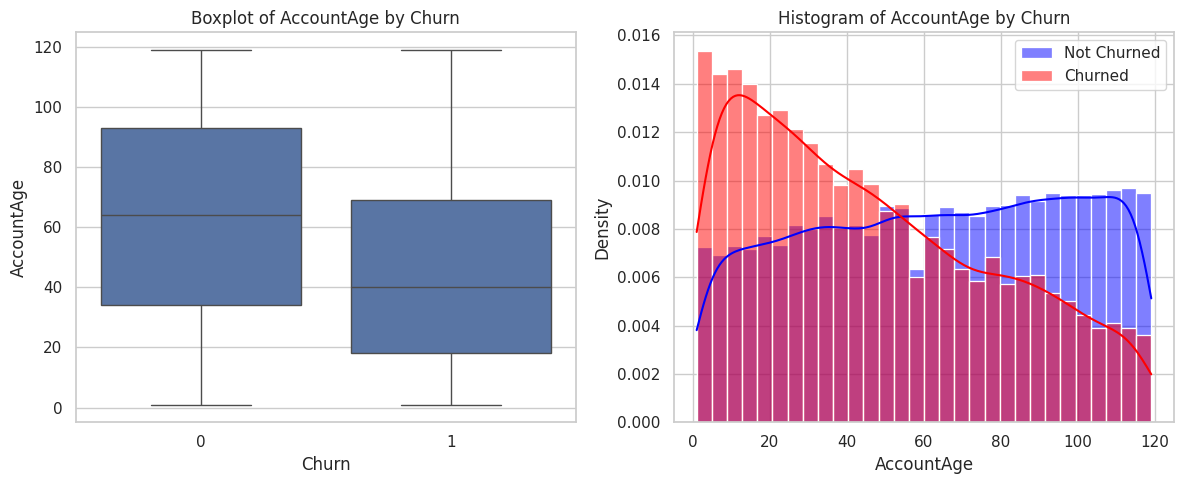

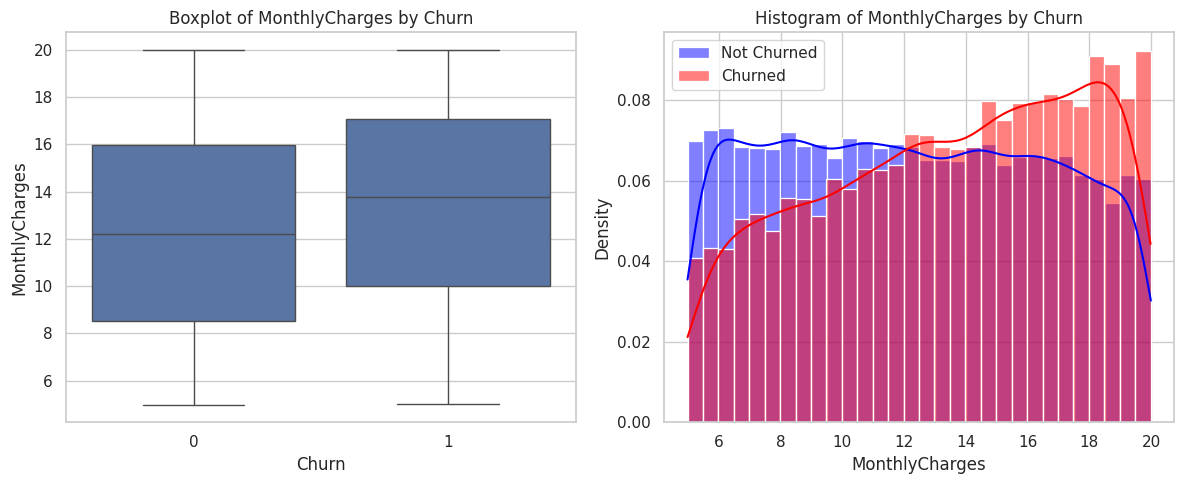

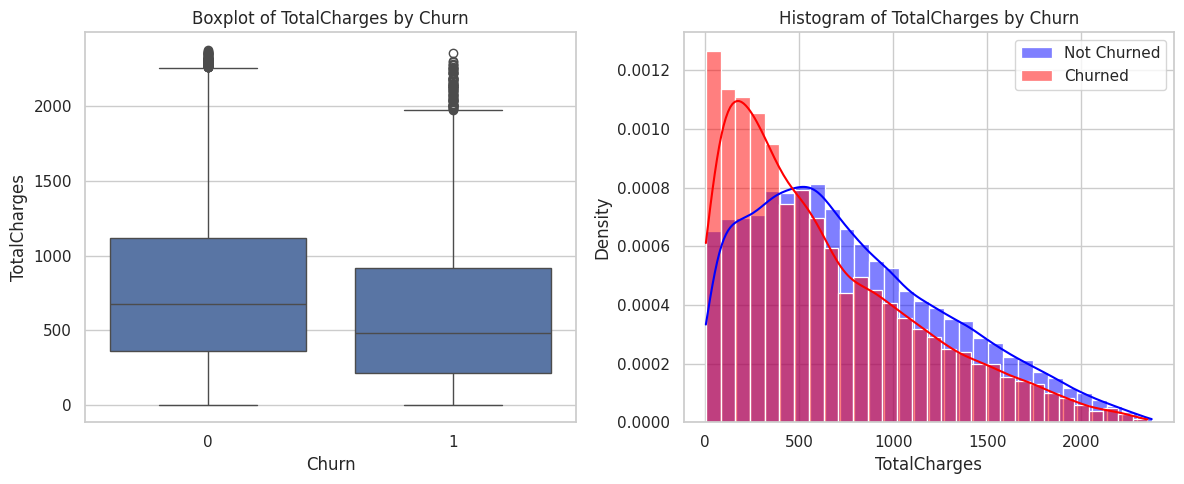

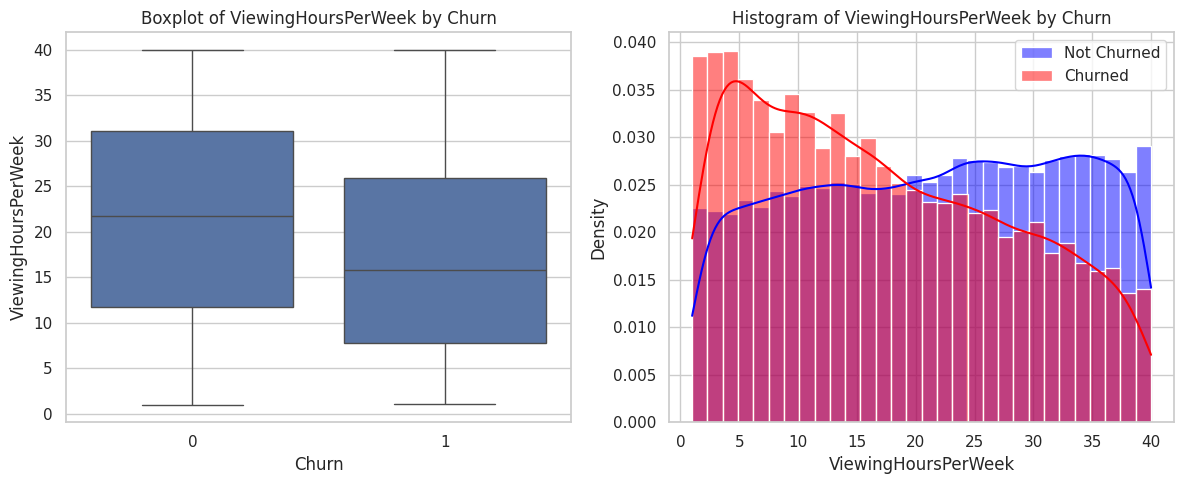

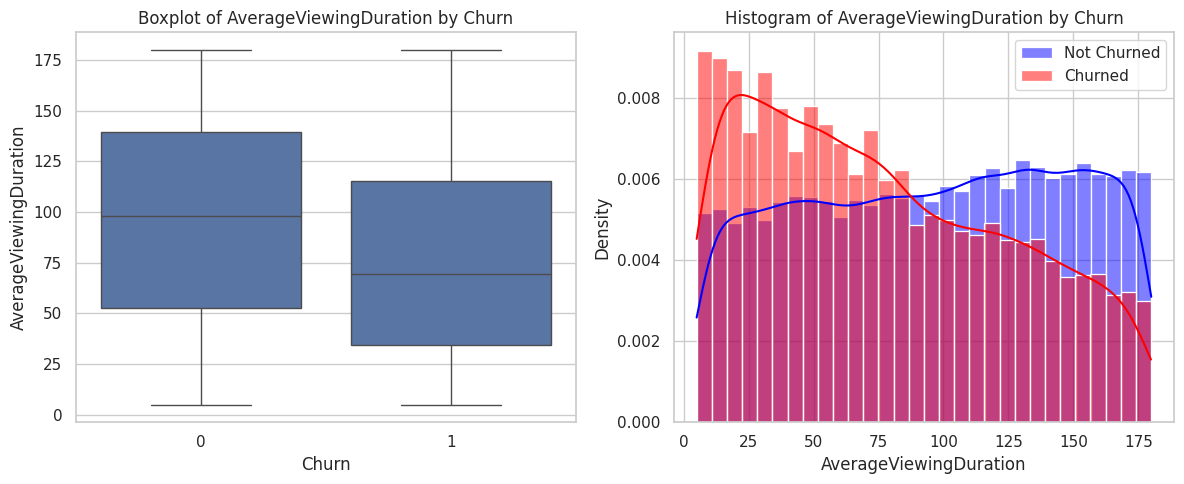

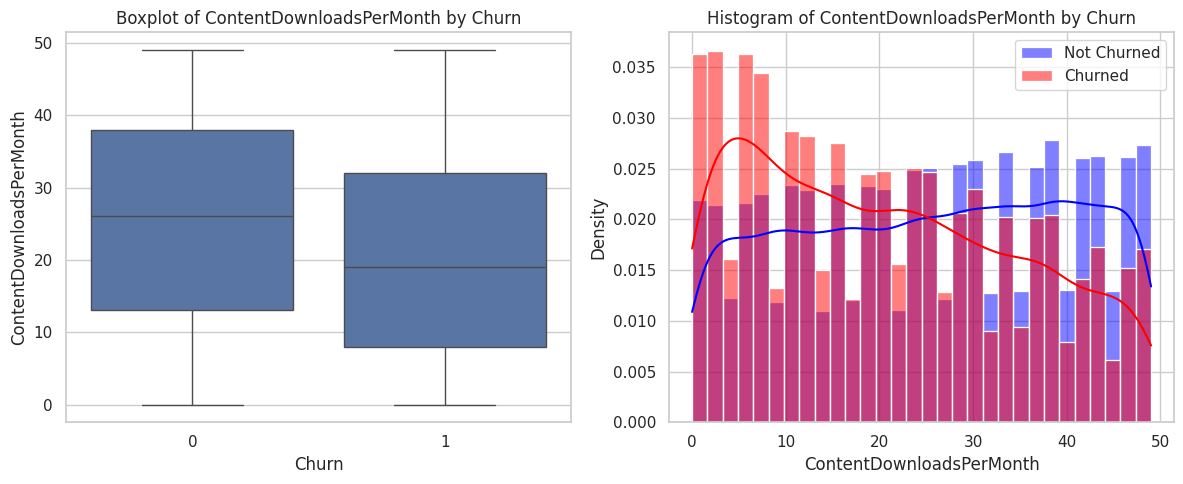

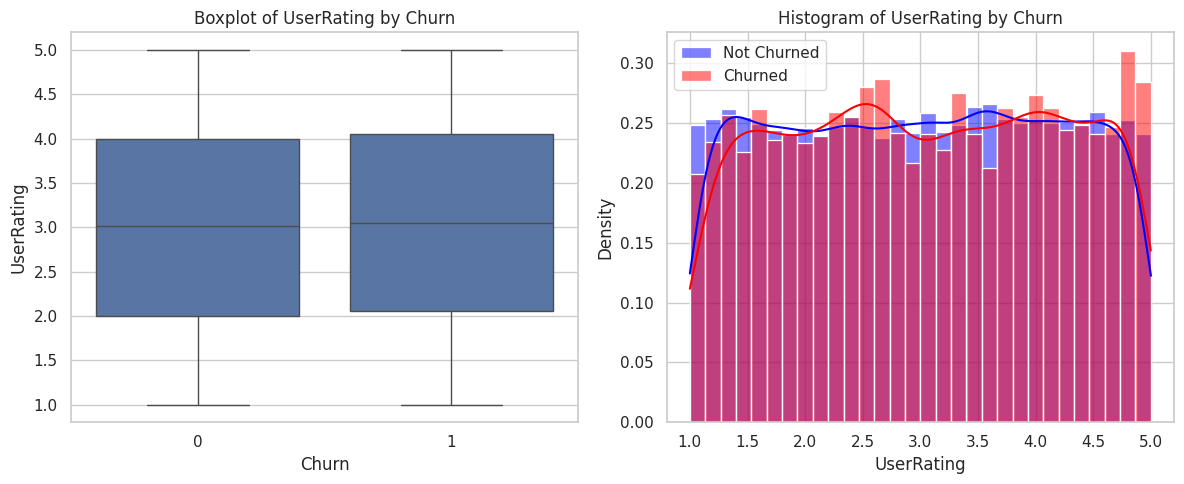

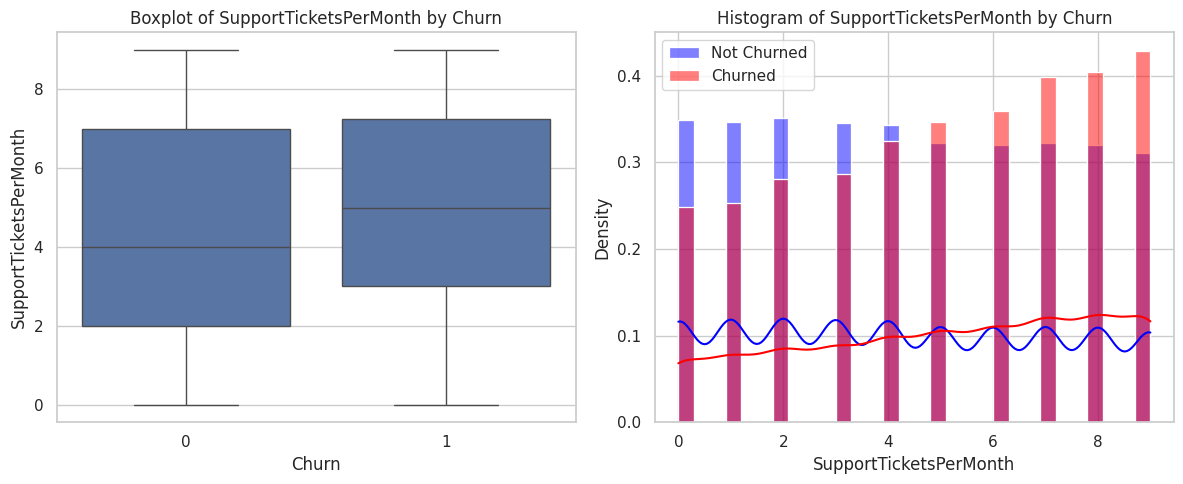

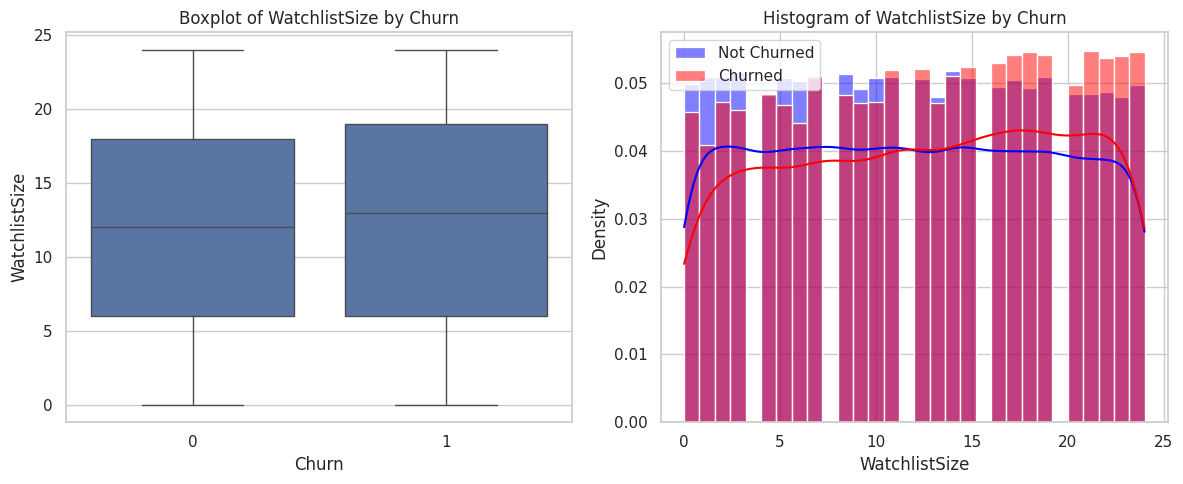

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set(style="whitegrid")

# List of features to explore
features_of_interest = [
    'AccountAge',
    'MonthlyCharges',
    'TotalCharges',
    'ViewingHoursPerWeek',
    'AverageViewingDuration',
    'ContentDownloadsPerMonth',
    'UserRating',
    'SupportTicketsPerMonth',
    'WatchlistSize'
]

# Function to create boxplots and histograms for features of interest
def explore_features(data, features):
    for feature in features:
        plt.figure(figsize=(12, 5))

        # Boxplot
        plt.subplot(1, 2, 1)
        sns.boxplot(x='Churn', y=feature, data=data)
        plt.title(f'Boxplot of {feature} by Churn')
        plt.xlabel('Churn')
        plt.ylabel(feature)

        # Histogram
        plt.subplot(1, 2, 2)
        sns.histplot(data[data['Churn'] == 0][feature], color='blue', label='Not Churned', bins=30, kde=True, stat='density')
        sns.histplot(data[data['Churn'] == 1][feature], color='red', label='Churned', bins=30, kde=True, stat='density')
        plt.title(f'Histogram of {feature} by Churn')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()

        plt.tight_layout()
        plt.show()

# Explore the specified features
explore_features(df, features_of_interest)


> Insights:
 Engagement-related features (e.g., ViewingHoursPerWeek, ContentDownloadsPerMonth, WatchlistSize) are likely strong indicators of churn. Customers who engage less with the service might be more likely to leave.
Pricing sensitivity (e.g., MonthlyCharges, TotalCharges) could play a role, particularly if churned customers tend to pay more or perceive less value from the service.
Customer support issues (e.g., SupportTicketsPerMonth) may also correlate with churn, as dissatisfied users are more likely to leave.
User Ratings might not be a strong differentiator, as seen from the visual similarities between churned and non-churned customers.

<Figure size 800x400 with 0 Axes>

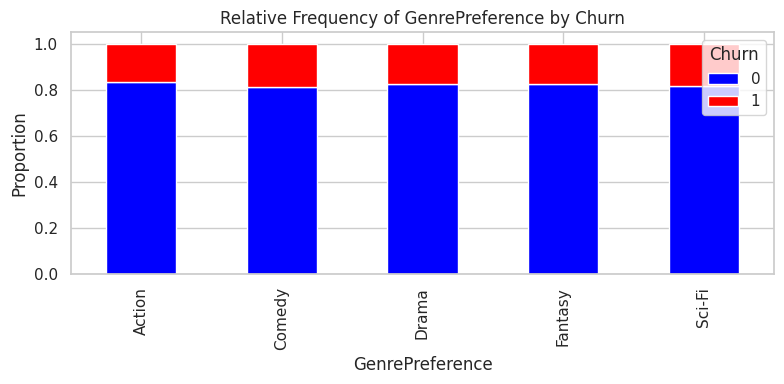

<Figure size 800x400 with 0 Axes>

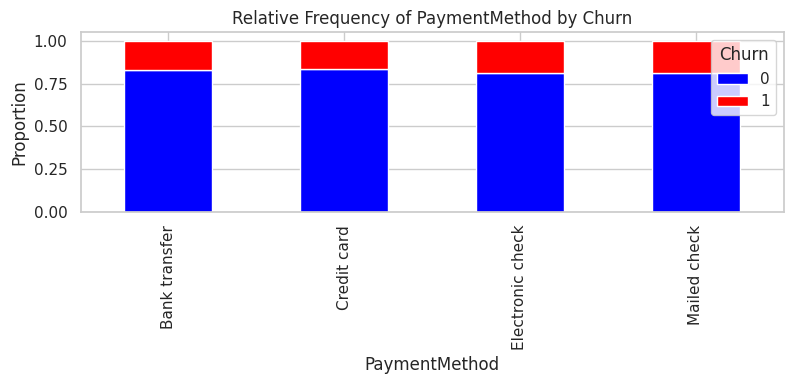

<Figure size 800x400 with 0 Axes>

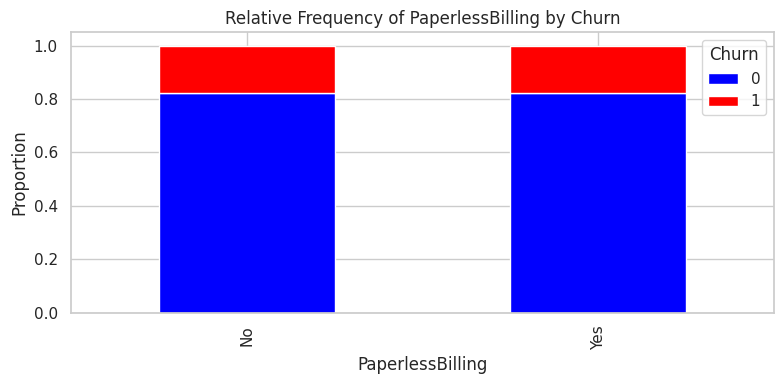

<Figure size 800x400 with 0 Axes>

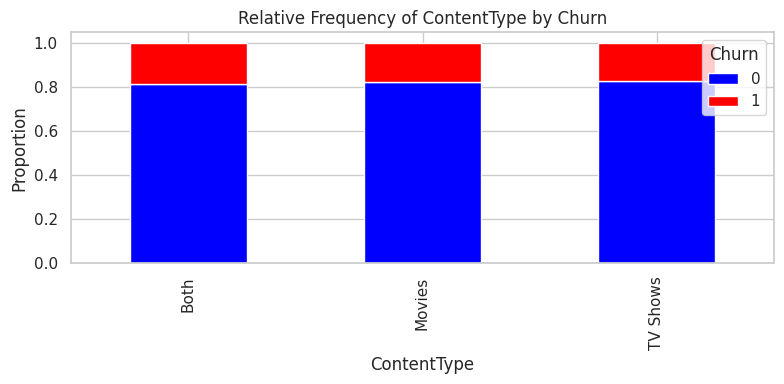

<Figure size 800x400 with 0 Axes>

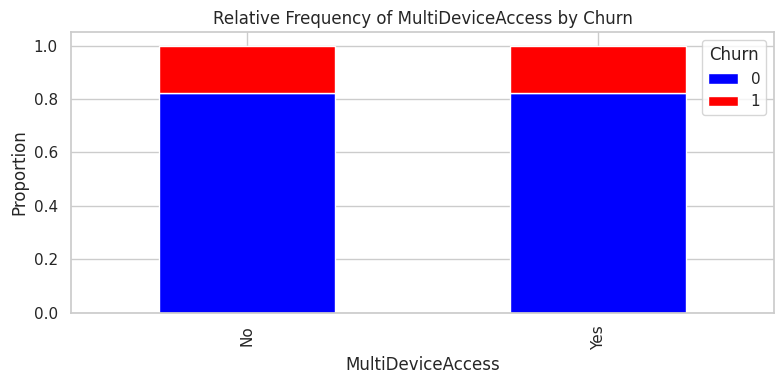

<Figure size 800x400 with 0 Axes>

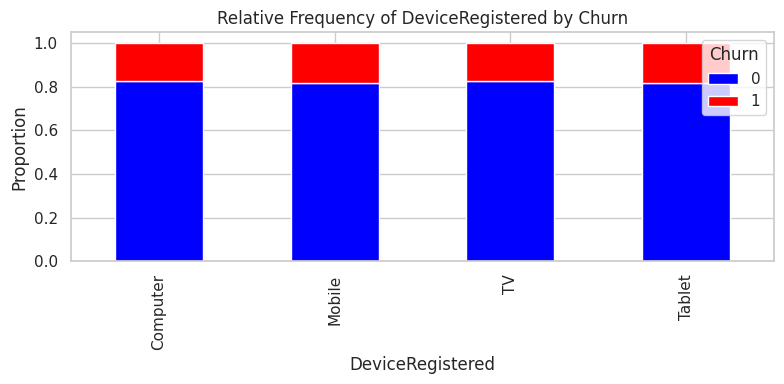

<Figure size 800x400 with 0 Axes>

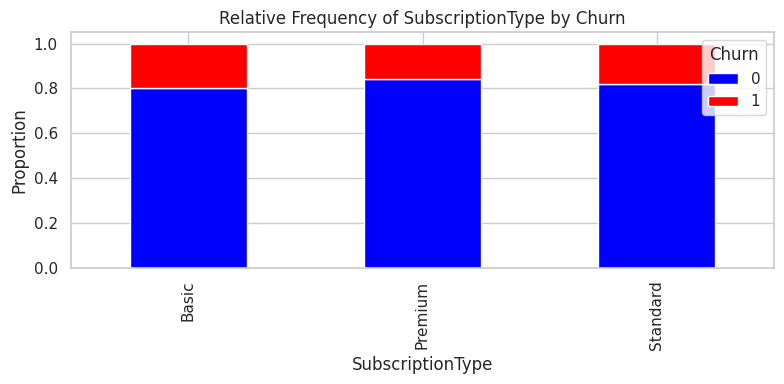

<Figure size 800x400 with 0 Axes>

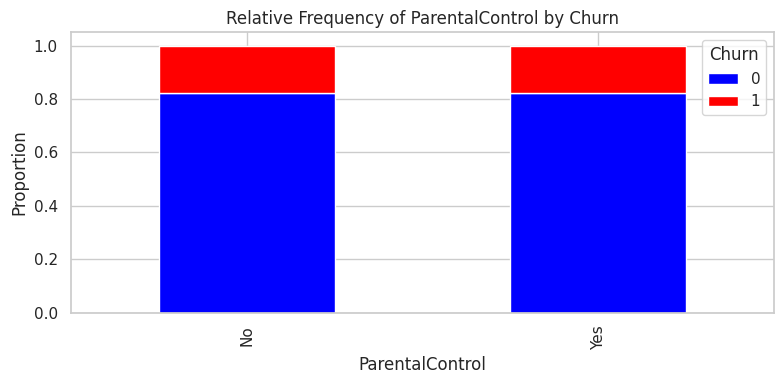

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set(style="whitegrid")

# List of categorical features to explore
categorical_features_of_interest = [
    'GenrePreference',
    'PaymentMethod',
    'PaperlessBilling',
    'ContentType',
    'MultiDeviceAccess',
    'DeviceRegistered',
    'SubscriptionType',
    'ParentalControl'
]

# Function to create quick relative frequency plots for categorical features
def relative_frequency_plot(data, features):
    for feature in features:
        plt.figure(figsize=(8, 4))

        # Normalize the count by converting it into percentages for each churn category
        churn_counts = pd.crosstab(data[feature], data['Churn'], normalize='index')
        churn_counts.plot(kind='bar', stacked=True, color=['blue', 'red'], figsize=(8, 4))

        plt.title(f'Relative Frequency of {feature} by Churn')
        plt.xlabel(feature)
        plt.ylabel('Proportion')
        plt.legend(title='Churn', loc='upper right')

        plt.tight_layout()
        plt.show()

# Explore the specified categorical features using relative frequency
relative_frequency_plot(df, categorical_features_of_interest)


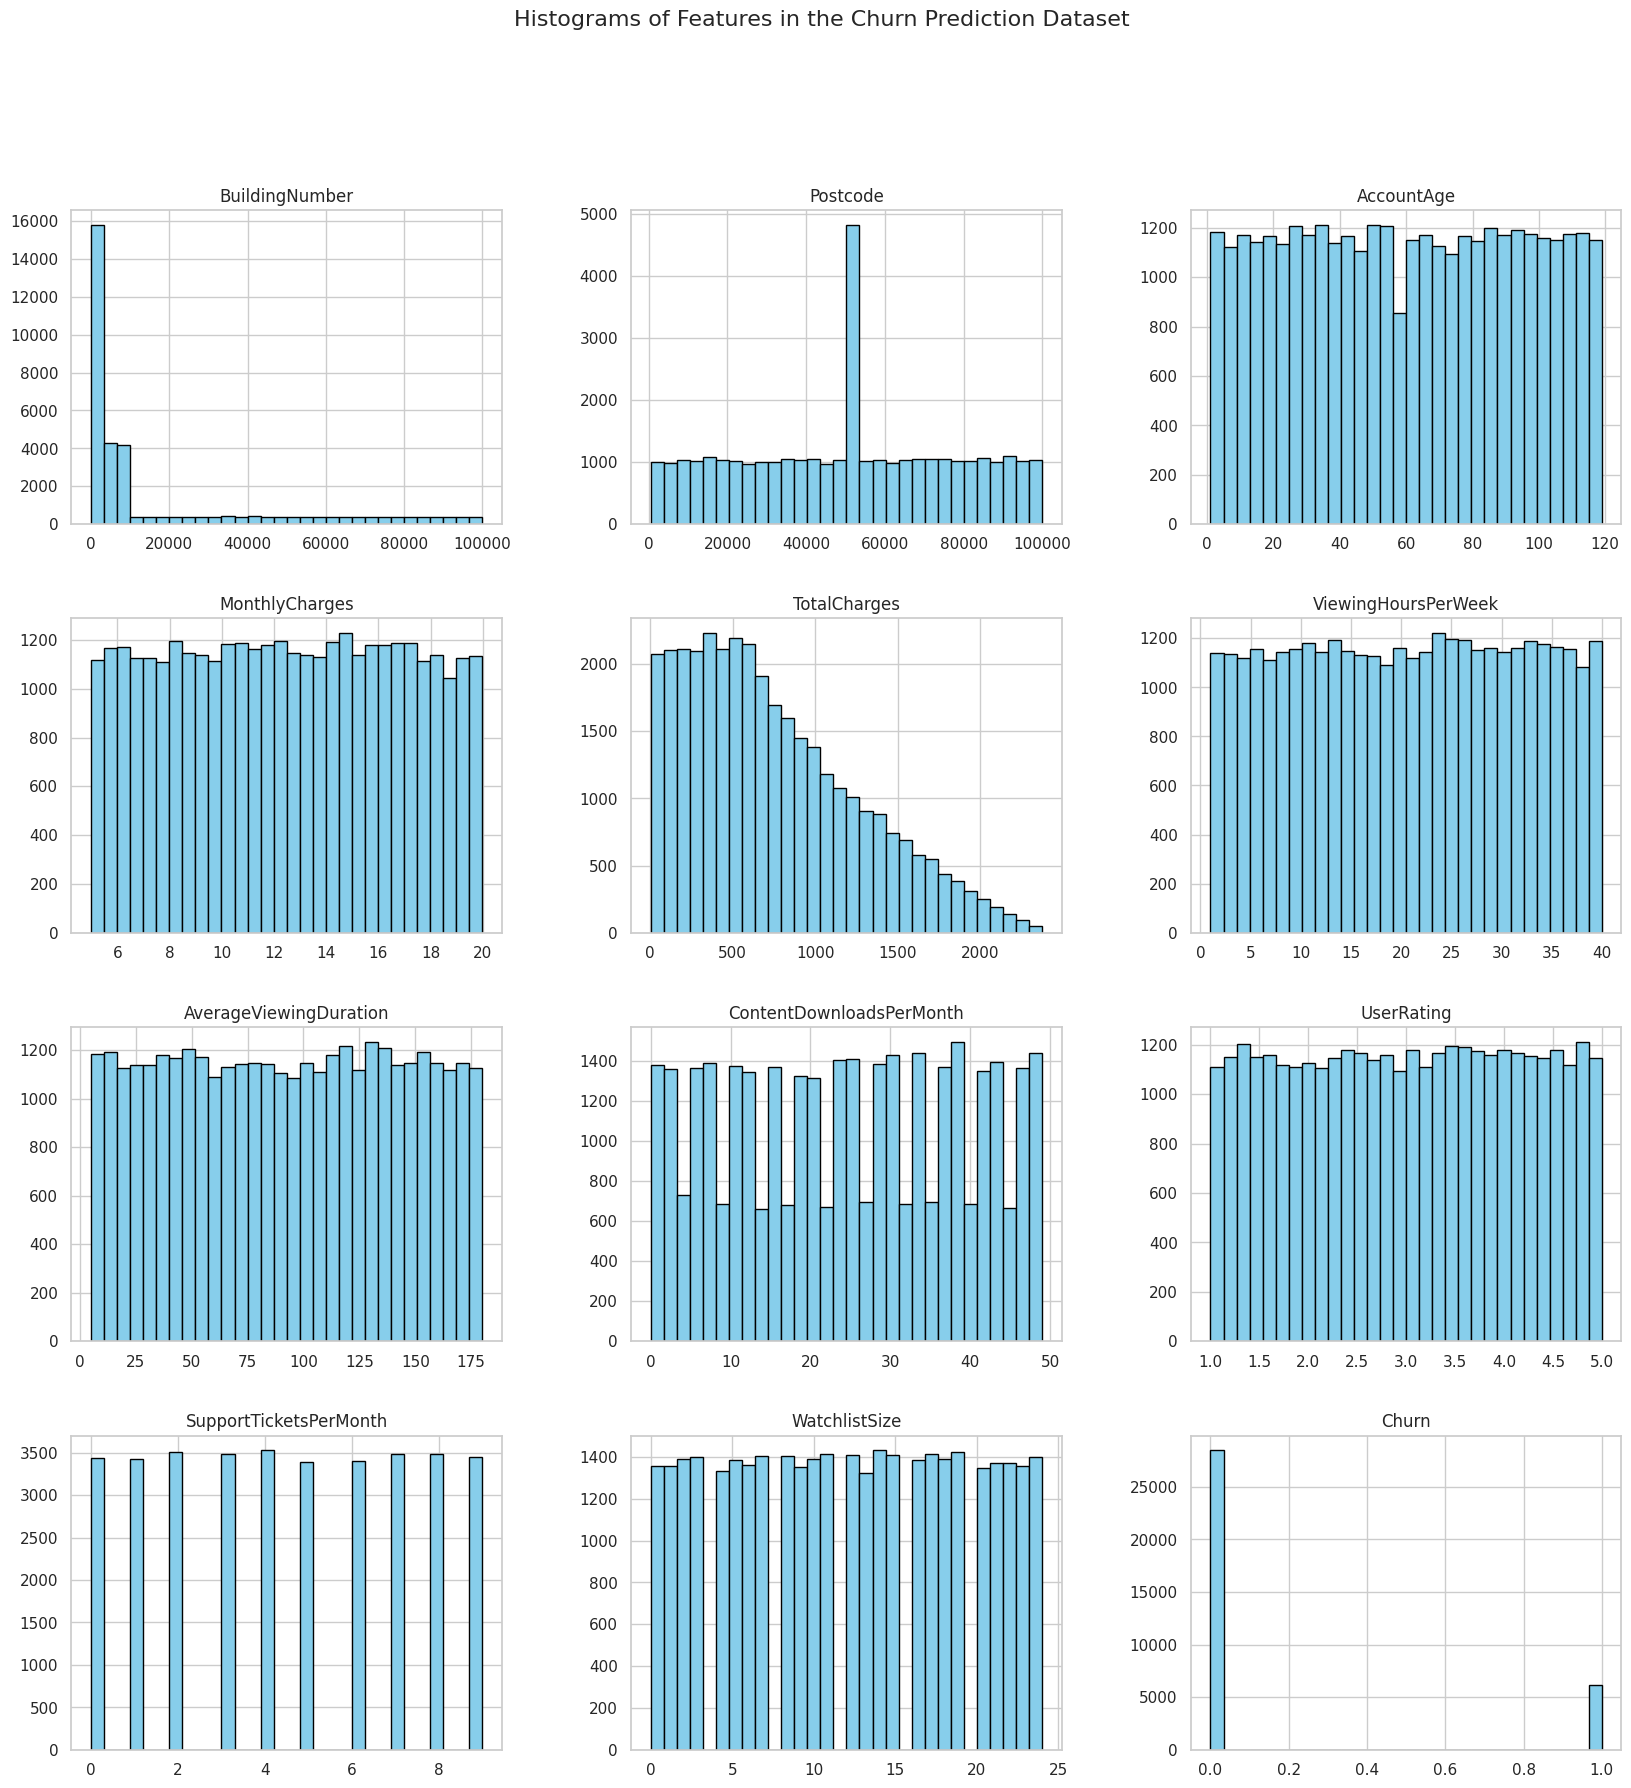

In [ ]:
# Explore the data with a histogram for each feature, using a custom color
df.hist(figsize=(20, 20), color='skyblue', edgecolor='black', bins=30)

# Set a common title for the plot
plt.suptitle('Histograms of Features in the Churn Prediction Dataset', fontsize=16)

# Show the plot
plt.show()



> Insights: This gives a visual sense of the distribution of the data.
This will help you visualize the distribution of your features in the dataset relevant to churn prediction.

> Issues found: The dataset shows significant class imbalance, with non-churned customers making up the majority. Several features, such as PaymentMethod and SubscriptionType, show little variation, which may limit their usefulness for predictive modeling. Additionally, skewed distributions and missing data in certain features could impact model performance and require appropriate handling.

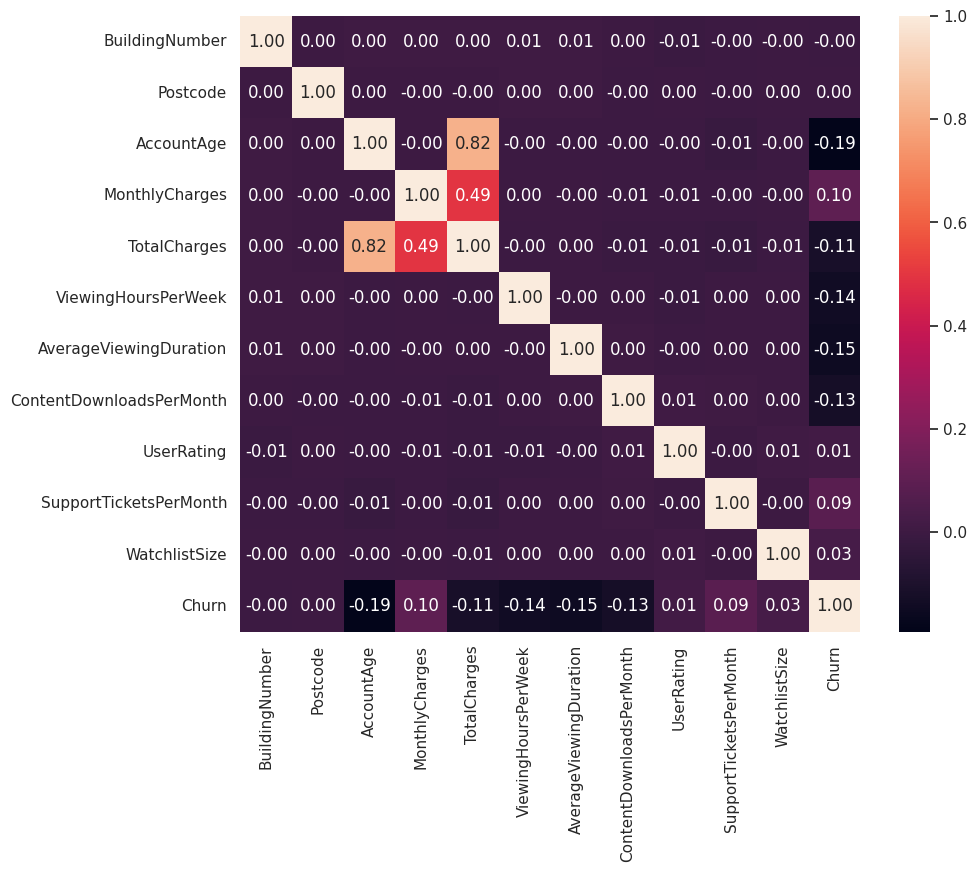

In [ ]:

# First, ensure the DataFrame only includes numeric columns for correlation computation
numeric_df = df.select_dtypes(include=[np.number])  # This ensures only numeric columns are included

# Now, plotting the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f")
plt.show()



Churn
0    82.247152
1    17.752848
Name: proportion, dtype: float64


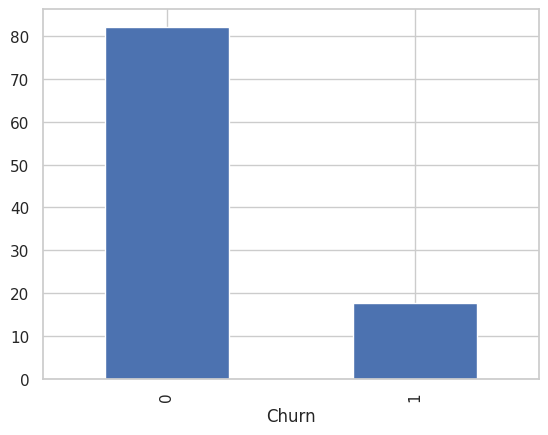

In [ ]:
churn_rate = 100 * df_combined['Churn'].value_counts(normalize=True)
print(churn_rate)
churn_rate.plot(kind='bar')
plt.show()

In [ ]:
num_df = df_combined.select_dtypes(np.number)
num_df

,BuildingNumber,Postcode,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
0,88588,46890.0,20,11.055215,221.104302,36.758104,63.531377,10,2.176498,4,3,0
1,69,NaN,57,5.175208,294.986882,32.450568,25.725595,18,3.478632,8,23,0
2,81311,12793.0,73,12.106657,883.785952,7.395160,57.364061,23,4.238824,6,1,0
3,115,56037.0,32,7.263743,232.439774,27.960389,131.537507,30,4.276013,2,24,0
4,674,99324.0,57,16.953078,966.325422,20.083397,45.356653,20,3.616170,4,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
34581,14356,NaN,113,8.852247,1000.303949,36.286152,17.915012,34,2.571882,5,3,0
34582,605,95400.0,42,10.983620,461.312027,17.487259,102.412522,9,2.361023,6,17,1
34583,179,NaN,43,11.959520,514.259343,26.355127,48.160768,17,3.695672,5,6,0
34584,762,36487.0,110,5.222484,574.473204,20.805085,54.255558,8,4.892557,1,5,0


#### C.4.a Feature "MonthlyCharges"

In [ ]:
df_combined["MonthlyCharges"].describe()

,MonthlyCharges
count,34586.000000
mean,12.481594
std,4.303706
min,4.990062
25%,8.744131
50%,12.472481
75%,16.174570
max,19.989412


Insights: The MonthlyCharges feature has no missing values, with a range between 4.99 and 19.98, and is evenly distributed across the dataset.

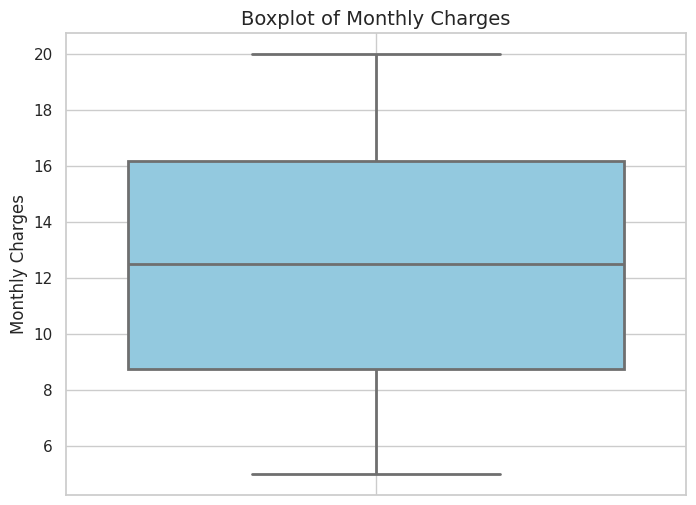

In [ ]:
#  Boxplot of MonthlyCharges to check for outliers
plt.figure(figsize=(8, 6))  # Set figure size for better readability
sns.boxplot(y=df_combined["MonthlyCharges"], color="skyblue", linewidth=2)

# Adding a title and labels for better context
plt.title("Boxplot of Monthly Charges", fontsize=14)
plt.ylabel("Monthly Charges", fontsize=12)

# Display the plot
plt.grid(True)  # Adding grid for better visual reference
plt.show()


Insights: There are no outliers present.

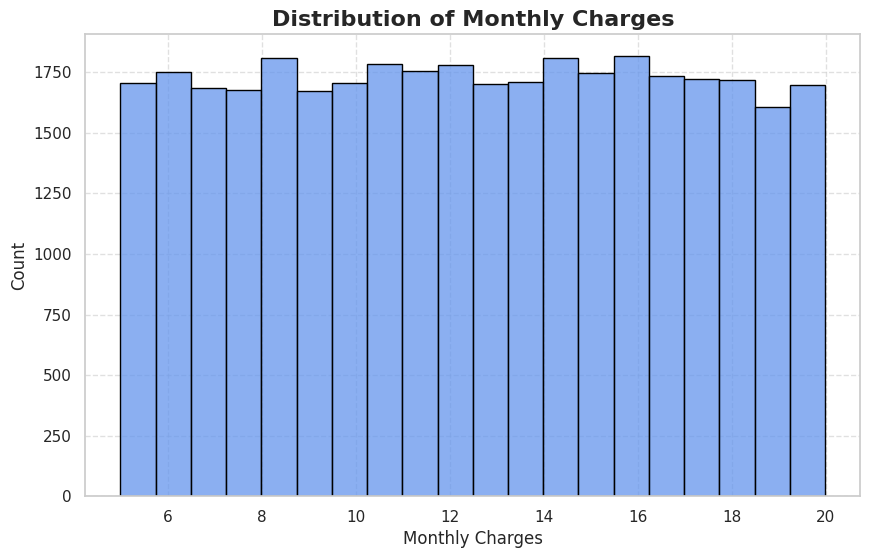

In [ ]:
# Enhanced Bar Plot of Monthly Charges Distribution
plt.figure(figsize=(10, 6))  # Set figure size

# Create the histogram using Seaborn with more customization
sns.histplot(df_combined['MonthlyCharges'], bins=20, kde=False, color="cornflowerblue", edgecolor="black")

# Adding labels and title for clarity
plt.xlabel('Monthly Charges', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Monthly Charges', fontsize=16, fontweight='bold')

# Adding gridlines for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()


>Considerations: MonthlyCharges can be segmented on the basis of SubscriptionType to understand if different packages affect churn differently.


Issues found: Due to its uniformity, MonthlyCharges may not have a diverse effect on Churn.

#### C.4.b Feature "UserRating"

In [ ]:
# Descriptive statistics of viewing hours per week

df_combined["UserRating"].describe()

,UserRating
count,34586.000000
mean,3.009000
std,1.154705
min,1.000007
25%,2.007270
50%,3.021349
75%,4.007800
max,4.999845


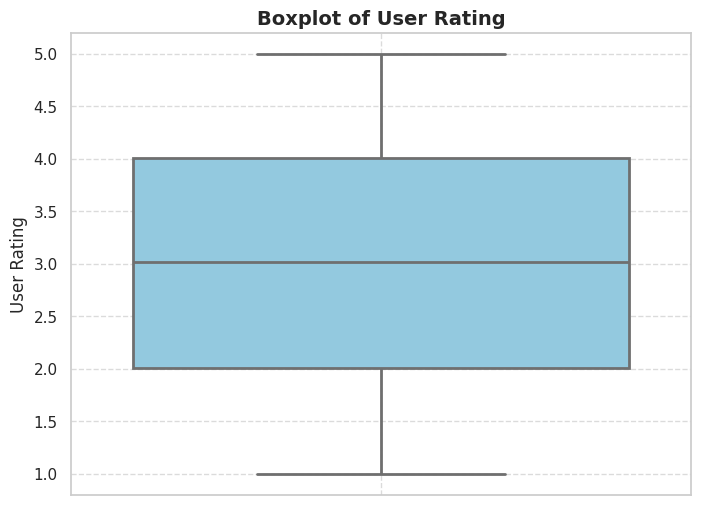

In [ ]:
# Boxplot of UserRating to check for outliers
plt.figure(figsize=(8, 6))  # Set figure size for better readability

# Create the boxplot with enhanced aesthetics
sns.boxplot(y=df_combined["UserRating"], color="skyblue", linewidth=2)

# Adding a title and labels for better context
plt.title("Boxplot of User Rating", fontsize=14, fontweight='bold')
plt.ylabel("User Rating", fontsize=12)

# Adding grid for better reference
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()


Insight: No outliers present

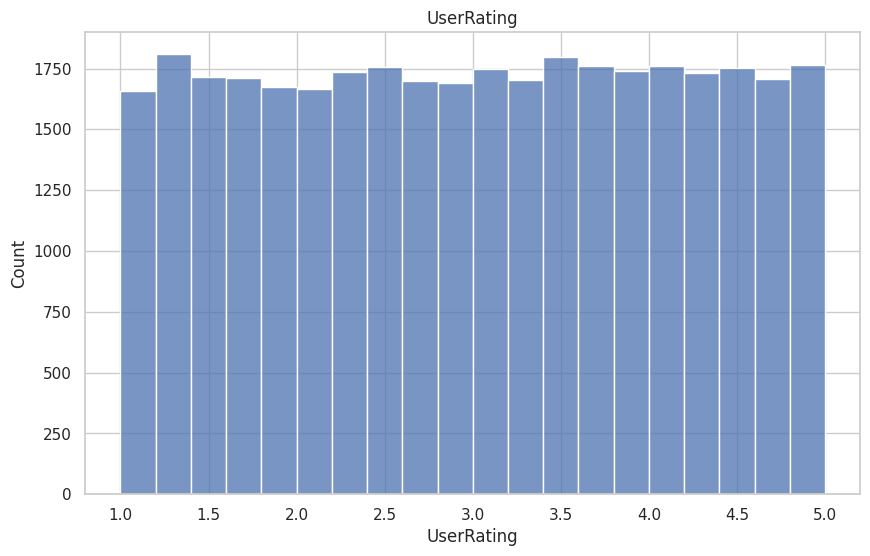

In [ ]:
# Create a bar plot with Seaborn
plt.figure(figsize=(10,6))
sns.histplot(df_combined['UserRating'], bins=20, kde=False)
plt.xlabel('UserRating')
plt.ylabel('Count')
plt.title('UserRating')
plt.show()

> Insights: The UserRating feature shows a balanced distribution across all rating levels, suggesting no dominant rating group among users.

> Considerations:
The UserRating distribution appears fairly uniform across all ratings, indicating that customer ratings are evenly spread from 1.0 to 5.0, with no significant skew or outliers.

> Issues found: There are no significant outliers or skewness in UserRating, but the uniform distribution may limit its predictive power for churn.

#### C.4.b Feature GenrePreference

In [ ]:
# Descriptive statistics of viewing hours per week

df_combined["GenrePreference"].describe()

,GenrePreference
count,34586
unique,5
top,Comedy
freq,7022


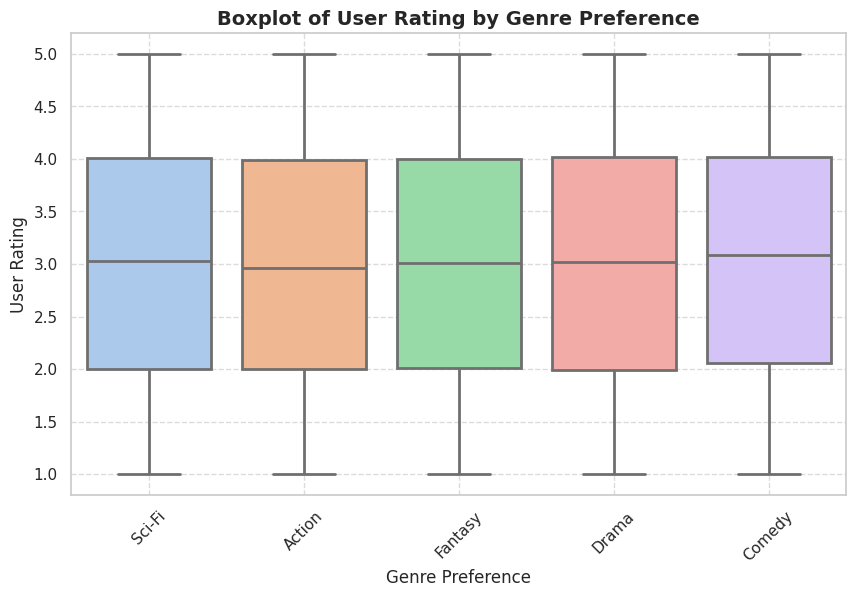

In [ ]:
# Boxplot of UserRating by GenrePreference to check for outliers
plt.figure(figsize=(10, 6))  # Set figure size for better readability

# Create the boxplot with enhanced aesthetics
sns.boxplot(x=df_combined["GenrePreference"], y=df_combined["UserRating"], palette="pastel", linewidth=2)

# Adding a title and labels for better context
plt.title("Boxplot of User Rating by Genre Preference", fontsize=14, fontweight='bold')
plt.xlabel("Genre Preference", fontsize=12)
plt.ylabel("User Rating", fontsize=12)

# Adding grid for better reference
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()


Insights: No outliers

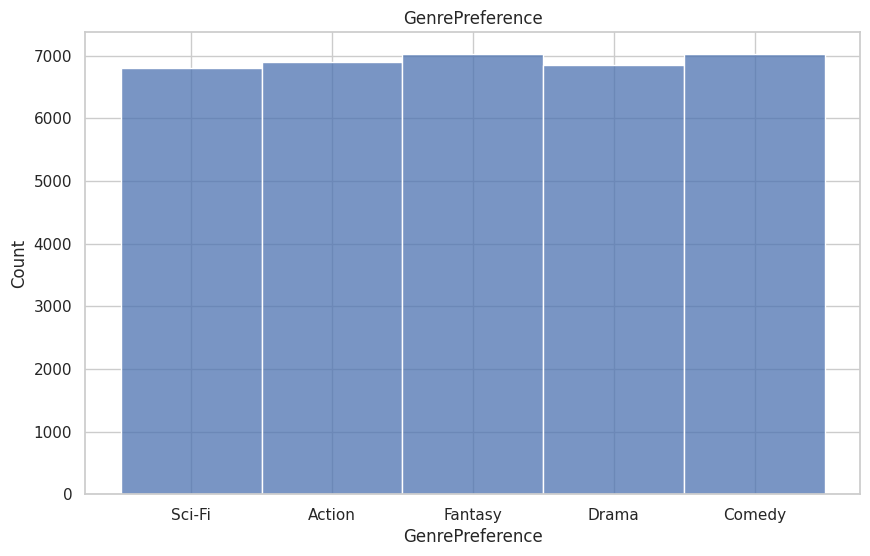

In [ ]:
# Create a bar plot with Seaborn
plt.figure(figsize=(10,6))
sns.histplot(df_combined['GenrePreference'], bins=20, kde=False)
plt.xlabel('GenrePreference')
plt.ylabel('Count')
plt.title('GenrePreference')
plt.show()

<hr>

Insights: The distribution of User Ratings across different GenrePreferences shows some variation, with certain genres receiving slightly higher or lower ratings, but overall, there is no drastic difference in user ratings based on genre. This suggests that GenrePreference may not have a strong influence on user ratings and might offer limited predictive power for churn.

Considerations: shows limited variation in user ratings, indicating it may have low predictive value for churn analysis.

Issues: The lack of significant variation in GenrePreference across user ratings suggests it may not be a strong predictor for churn.

## D. Feature Selection


In [ ]:
feature_selection_executive_summary = 'The feature selection process identified the most relevant features, reducing dimensionality and improving model efficiency by focusing on key predictors of customer churn, such as DeviceRegistered, ParentalControl, SubscriptionType'

### D.1 Approach 1

> Rationale: Feature selection was performed to improve model efficiency and performance by focusing on the most relevant features that have the greatest impact on predicting customer churn.

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.impute import SimpleImputer
import pandas as pd

# Define the target variable name (assuming target_name is defined)
target_name = 'Churn'  # Update this based on your actual target column

# Separate the features (X) and target (y)
X_train = num_df.drop(target_name, axis=1)
y_train = num_df[target_name]

# Impute missing values in the feature set
imputer = SimpleImputer(strategy='mean')  # You can use 'mean', 'median', or other strategies
X_train_imputed = imputer.fit_transform(X_train)

# Apply SelectKBest to find the best features
selector = SelectKBest(k=5)
selector.fit(X_train_imputed, y_train)

# Get the selected features
selected_features = X_train.columns[selector.get_support()]

# Print the best subset of features
print("Best subset of features:")
print(selected_features)
print('\n')
print("Original set of features:")
print(num_df.columns)


Best subset of features:
Index(['AccountAge', 'TotalCharges', 'ViewingHoursPerWeek',
       'AverageViewingDuration', 'ContentDownloadsPerMonth'],
      dtype='object')


Original set of features:
Index(['BuildingNumber', 'Postcode', 'AccountAge', 'MonthlyCharges',
       'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration',
       'ContentDownloadsPerMonth', 'UserRating', 'SupportTicketsPerMonth',
       'WatchlistSize', 'Churn'],
      dtype='object')


In [ ]:
# Check for unique values in categorical columns
categorical_columns = df_combined.select_dtypes(include=['object']).columns

# Show the number of unique values for each categorical feature
for col in categorical_columns:
    print(f'{col}: {df_combined[col].nunique()} unique values')

FirstName: 2247 unique values
LastName: 8660 unique values
StreetName: 29006 unique values
StreetType: 195 unique values
City: 22076 unique values
State: 59 unique values
Ethnicity: 4 unique values
SubscriptionType: 3 unique values
PaymentMethod: 4 unique values
PaperlessBilling: 2 unique values
ContentType: 3 unique values
MultiDeviceAccess: 2 unique values
DeviceRegistered: 4 unique values
GenrePreference: 5 unique values
Gender: 2 unique values
ParentalControl: 2 unique values
SubtitlesEnabled: 2 unique values
CustomerID: 34586 unique values
Cohort: 29907 unique values


In [ ]:
import scipy.stats as stats
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Compute Cramér's V for each categorical feature
for col in categorical_columns:
    confusion_matrix = pd.crosstab(df_combined[col], df_combined['Churn'])
    print(f"Cramér's V for {col}: {cramers_v(confusion_matrix)}")

Cramér's V for FirstName: Churn
0    0.286344
1    0.616332
dtype: float64
Cramér's V for LastName: Churn
0    0.554884
1    1.194397
dtype: float64
Cramér's V for StreetName: Churn
0    1.011221
1    2.176570
dtype: float64
Cramér's V for StreetType: Churn
0    0.078104
1    0.168113
dtype: float64
Cramér's V for City: Churn
0    0.885850
1    1.906719
dtype: float64
Cramér's V for State: Churn
0    0.047012
1    0.101327
dtype: float64
Cramér's V for Ethnicity: Churn
0    0.013913
1    0.029965
dtype: float64
Cramér's V for SubscriptionType: Churn
0    0.046681
1    0.100478
dtype: float64
Cramér's V for PaymentMethod: Churn
0    0.031271
1    0.067308
dtype: float64
Cramér's V for PaperlessBilling: Churn
0    0.002718
1    0.005851
dtype: float64
Cramér's V for ContentType: Churn
0    0.014804
1    0.031865
dtype: float64
Cramér's V for MultiDeviceAccess: Churn
0    0.002507
1    0.005395
dtype: float64
Cramér's V for DeviceRegistered: Churn
0    0.014790
1    0.031834
dtype: float6

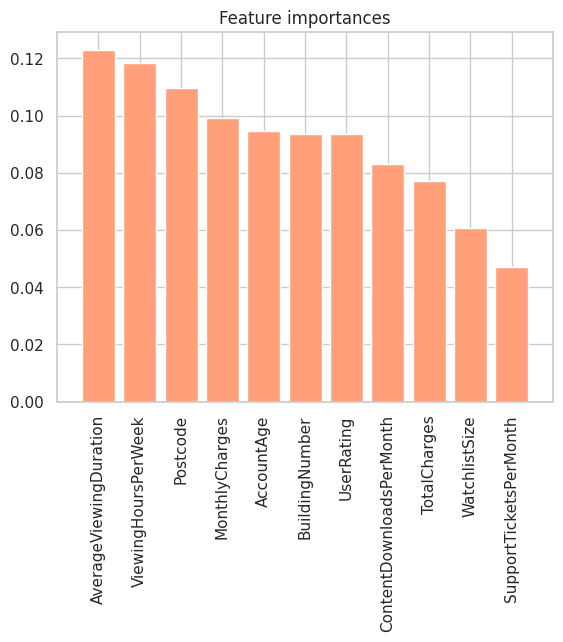

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.title("Feature importances")
plt.bar(range(X_train.shape[1]), importances[indices], color="lightsalmon", align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)  # Using column names instead of indices
plt.xlim([-1, X_train.shape[1]])
plt.show()

> Results: From above analysis, I decided to choose, 'DeviceRegistered', 'ParentalControl', 'SubscriptionType'

### D.2 Approach 2

> Rationale: Handling missing values and standardizing numeric features while encoding categorical variables to ensure effective feature selection and improved model performance.

In [ ]:
# ---- Data Loading ---- #
df = pd.read_csv('/content/combined_dataset.csv')
y = df['Churn']

# ---- Preprocessing: Imputation & Scaling for Numeric Features ---- #
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_features.remove('Churn')  # Ensure 'Churn' is not treated as a numeric feature

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values
    ('scaler', StandardScaler())  # Standardize the numeric features
])

# ---- Preprocessing: One-Hot Encoding for Categorical Features ---- #
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encoding
])

# ---- Combine Numeric and Categorical Preprocessing ---- #
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing Steps:")
print(f"Numeric Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")
print("Data preprocessing has been set up to handle missing values and standardize numeric features, while also encoding categorical variables.")



Preprocessing Steps:
Numeric Features: ['BuildingNumber', 'Postcode', 'AccountAge', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'UserRating', 'SupportTicketsPerMonth', 'WatchlistSize']
Categorical Features: ['FirstName', 'LastName', 'StreetName', 'StreetType', 'City', 'State', 'Ethnicity', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled', 'CustomerID', 'Cohort']
Data preprocessing has been set up to handle missing values and standardize numeric features, while also encoding categorical variables.


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# ---- Data Loading ---- #
df = pd.read_csv('/content/combined_dataset.csv')
y = df['Churn']

print("Data loaded successfully!")
print(f"Dataset shape: {df.shape}")
print(f"Target variable (Churn) distribution:\n{y.value_counts()}")

# ---- Preprocessing: Imputation & Scaling for Numeric Features ---- #
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_features.remove('Churn')  # Ensure 'Churn' is not treated as a numeric feature
print(f"Numeric features: {numeric_features}")

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values
    ('scaler', StandardScaler())  # Standardize the numeric features
])
print("Numeric features preprocessing pipeline created (imputation and scaling).")

# ---- Preprocessing: One-Hot Encoding for Categorical Features ---- #
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features: {categorical_features}")

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # One-hot encoding
])
print("Categorical features preprocessing pipeline created (imputation and one-hot encoding).")

# ---- Combine Numeric and Categorical Preprocessing ---- #
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print("Preprocessing pipeline created (numeric and categorical combined).")


Data loaded successfully!
Dataset shape: (34586, 31)
Target variable (Churn) distribution:
Churn
0    28446
1     6140
Name: count, dtype: int64
Numeric features: ['BuildingNumber', 'Postcode', 'AccountAge', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'ContentDownloadsPerMonth', 'UserRating', 'SupportTicketsPerMonth', 'WatchlistSize']
Numeric features preprocessing pipeline created (imputation and scaling).
Categorical features: ['FirstName', 'LastName', 'StreetName', 'StreetType', 'City', 'State', 'Ethnicity', 'SubscriptionType', 'PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled', 'CustomerID', 'Cohort']
Categorical features preprocessing pipeline created (imputation and one-hot encoding).
Preprocessing pipeline created (numeric and categorical combined).


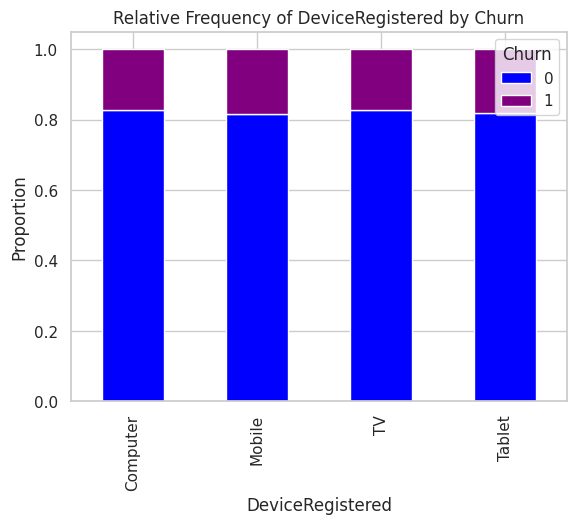

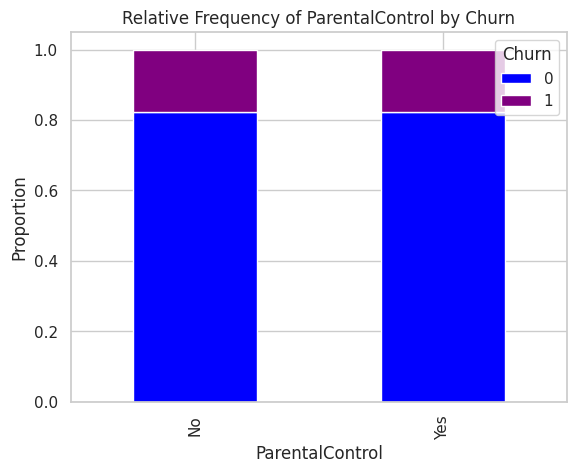

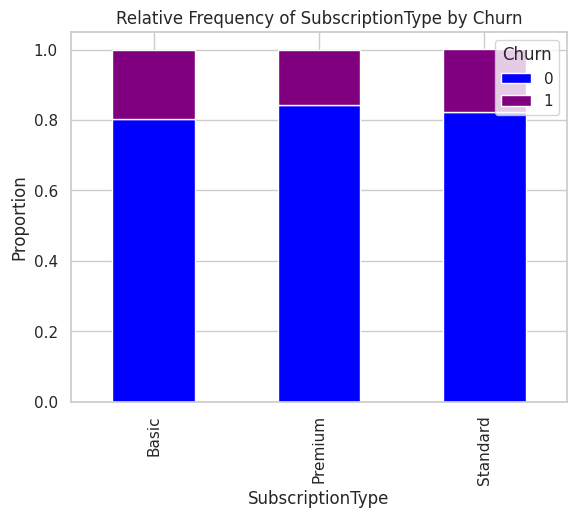

In [ ]:

df = pd.read_csv('/content/combined_dataset.csv')
# Set the style for seaborn
sns.set(style="whitegrid")

# List of categorical features to explore
categorical_features_of_interest = [
    'DeviceRegistered', 'ParentalControl', 'SubscriptionType'
]

# Function to create quick relative frequency plots for categorical features
def relative_frequency_plot(data, features):
    for feature in features:
        # Calculate the proportion of churn for each feature
        churn_counts = pd.crosstab(data[feature], data['Churn'], normalize='index')

        # Create a stacked bar plot
        churn_counts.plot(kind='bar', stacked=True, color=['blue', 'purple'])

        plt.title(f'Relative Frequency of {feature} by Churn')
        plt.xlabel(feature)
        plt.ylabel('Proportion')
        plt.legend(title='Churn', loc='upper right')
        plt.show()

# Explore the specified categorical features using relative frequency
relative_frequency_plot(df, categorical_features_of_interest)


> Results: <fill_this>

### D.3 Final Selection of Features

In [ ]:

final_selected_features = ['MonthlyCharges','UserRating','DeviceRegistered', 'ParentalControl', 'SubscriptionType']

print("Final selected features:", final_selected_features)

Final selected features: ['MonthlyCharges', 'UserRating', 'DeviceRegistered', 'ParentalControl', 'SubscriptionType']


<hr>

## E. Data Cleaning


In [ ]:
data_cleaning_executive_summary = 'The data cleaning process combined multiple datasets, handled missing values, encoded the target variable, standardized features, and identified the top 5 predictive features of churn using logistic regression and RFE.'

<hr>

### E.1 Fixing "Churn"

> Rationale: This code cleans the Churn column by converting categorical values ('Yes' and 'No') into binary numeric values (1 and 0) to facilitate effective modeling.

In [ ]:
# Cleaning Churn column, ensuring binary 0 and 1 values
df['Churn'] = df['Churn'].replace(['Yes', 'No'], [1, 0])


> Results: The Churn column now contains binary values, enabling the model to accurately interpret and predict customer churn.

<hr>

### E.2 Fixing "AccountAge"

> Rationale: This code cleans the AccountAge column by replacing any 'NaN' strings with actual NaN values and converting the column to numeric format, ensuring that all entries are valid for analysis.

In [ ]:
# <fill_this>
# Cleaning AccountAge column, ensuring it contains valid numeric values
df['AccountAge'] = df['AccountAge'].replace({'NaN': None})  # Replace 'NaN' string with actual NaN if present
df['AccountAge'] = pd.to_numeric(df['AccountAge'], errors='coerce')  # Convert to numeric, setting invalid entries to NaN


> Results: The AccountAge column is now comprised of valid numeric values, with any invalid entries replaced by NaN, allowing for accurate calculations and model training.

<hr>

### E.3 Fixing "MonthlyCharges"

> Rationale:  This code converts the MonthlyCharges column to a numeric format, replacing invalid entries with NaN, and then imputes missing values using the median to maintain data integrity for analysis.

In [ ]:
# Cleaning MonthlyCharges column, ensuring it contains valid numeric values
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')  # Convert to numeric, setting invalid entries to NaN
df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())  # Impute missing values with the median



> Results: The MonthlyCharges column now contains valid numeric values, with missing entries filled with the median, ensuring the dataset is ready for accurate modeling.

<hr>

## F. Feature Engineering

In [ ]:
feature_engineering_executive_summary = 'New features were created based on customer usage and financial activity to enhance model accuracy.'

<hr>

<hr>

### F.1 New Feature "ChurnRatio"

> Rationale: This code calculates the Churn Ratio by dividing TotalCharges by MonthlyCharges, providing a new feature that helps assess the relationship between total spending and monthly charges, which may indicate customer value or churn risk.

In [ ]:
# Churn Ratio: TotalCharges to MonthlyCharges ratio
df['ChurnRatio'] = df['TotalCharges'] / df['MonthlyCharges']

> Results: The ChurnRatio column has been added to the dataset, offering insights into customer spending patterns that could be relevant for churn analysis.

<hr>

### F.2 New Feature "TotalViewingHours"

> Rationale:This code creates the TotalViewingHours feature by multiplying ViewingHoursPerWeek by 52 to estimate the annual viewing hours, providing a clearer perspective on customer engagement over a year.

In [ ]:
# Create TotalViewingHours by multiplying ViewingHoursPerWeek by 52
df['TotalViewingHours'] = df['ViewingHoursPerWeek'] * 52



> Results: The TotalViewingHours column has been added to the dataset, enhancing the understanding of customer viewing habits and their potential correlation with churn.

<hr>

### F.3 New Feature "ChargePerHourViewed"

> Rationale: This code calculates the ChargePerHourViewed feature by dividing TotalCharges by TotalViewingHours, providing insight into the cost efficiency of customer engagement relative to their viewing habits.

In [ ]:

# Create ChargePerHourViewed by dividing TotalCharges by TotalViewingHours
df['ChargePerHourViewed'] = df['TotalCharges'] / df['TotalViewingHours']




> Results: The ChargePerHourViewed column has been added to the dataset, allowing for a better understanding of customer spending in relation to their viewing activity.

<hr>

## G. Data Preparation for Modeling


In [ ]:
modeling_preparation_executive_summary = 'Data is prepared by splitting into training, validation, and test sets and applying necessary transformations.'

<hr>

### G.1 Split Datasets

> Rationale: This code preprocesses the dataset by replacing categorical churn values with binary numeric values, splitting the data into training, validation, and test sets, and setting up a pipeline to impute missing values and encode categorical features, ensuring the data is ready for modeling.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Encode the 'Churn' column
df['Churn'] = df['Churn'].replace(['Yes', 'No'], [1, 0])  # Ensure binary values

# Define features (X) and target (y)
X = df.drop(columns=['Churn'])  # All features except target
y = df['Churn']  # Target variable

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Further split the training set into validation (25% of original) and test (10% of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Define a column transformer for numeric and categorical features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),  # Impute median for numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)  # Use sparse_output=False
    ])



In [ ]:
from scipy.sparse import csr_matrix
# Encode the 'Churn' column
df['Churn'] = df['Churn'].replace(['Yes', 'No'], [1, 0])  # Ensure binary values

# Define features (X) and target (y)
X = df.drop(columns=['Churn'])  # All features except target
y = df['Churn']  # Target variable

# Split the dataset into training and test sets (80% train, 20% test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Further split the temp set into validation (25% of original) and test (10% of original)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Define a column transformer for numeric and categorical features
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Create a preprocessing pipeline (use sparse_output=True for categorical features to save memory)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),  # Impute median for numeric features
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)  # Use sparse_output=True
    ])



> Results: The dataset has been effectively prepared for analysis, with distinct sets for training, validation, and testing, and a preprocessing pipeline established to handle missing data and categorical features.








<hr>

### G.2 Data Transformation <put_name_here>

> Rationale: This code fits and transforms the training data using the defined preprocessing pipeline, ensuring proper handling of missing values and encoding for categorical features, and then scales the numeric features to maintain their distribution while preserving the sparse structure of the dataset.

In [ ]:
# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Scale the numeric features only
scaler = StandardScaler(with_mean=False)  # Keep sparse structure intact
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)
X_test_scaled = scaler.transform(X_test_processed)

> Results:  The training, validation, and test datasets have been processed and scaled, resulting in ready-to-use feature matrices for model training and evaluation.








<hr>

### G.4 Data Transformation <put_name_here>

> Rationale: This code sets up a preprocessing pipeline that combines separate handling for numeric and categorical features, ensuring that missing values are imputed appropriately and numeric features are scaled while categorical features are one-hot encoded. By using a Pipeline and ColumnTransformer, the code streamlines data preprocessing, preparing the datasets for effective model training and evaluation.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd

# Example: Assuming X_train contains both numeric and categorical columns

# Define the numeric and categorical features
numeric_features = ['MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek']  # Update with your actual numeric features
categorical_features = ['GenrePreference', 'ParentalControl', 'PaymentMethod']  # Update with your actual categorical features

# Define preprocessing steps for numeric and categorical data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Impute missing values with the mean
    ('scaler', StandardScaler())  # Scale the numeric features
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Impute missing values with the most frequent value
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  # One-hot encode categorical features
])

# Combine numeric and categorical transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Use a pipeline to enforce the order of operations
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit and transform the training data, and transform the validation and test sets
X_train_transformed = pipeline.fit_transform(X_train)
X_val_transformed = pipeline.transform(X_val)
X_test_transformed = pipeline.transform(X_test)

# Print the shapes of the transformed datasets to verify the transformations
print(f"Transformed training data shape: {X_train_transformed.shape}")
print(f"Transformed validation data shape: {X_val_transformed.shape}")
print(f"Transformed test data shape: {X_test_transformed.shape}")

# Print the types of the transformed data to ensure they're as expected (e.g., sparse matrix)
print(f"Training data type: {type(X_train_transformed)}")
print(f"Validation data type: {type(X_val_transformed)}")
print(f"Test data type: {type(X_test_transformed)}")


Transformed training data shape: (27668, 14)
Transformed validation data shape: (3459, 14)
Transformed test data shape: (3459, 14)
Training data type: <class 'numpy.ndarray'>
Validation data type: <class 'numpy.ndarray'>
Test data type: <class 'numpy.ndarray'>


> Results: The training, validation, and test datasets have been transformed into a format suitable for modeling, with their shapes confirmed to reflect the expected changes, and the types of the transformed data are verified to be consistent with the preprocessing steps (e.g., sparse matrices for one-hot encoded features).








<hr>

## H. Save Datasets

In [ ]:
# Save training set
# Do not change this code

X_train.to_csv('X_train.csv', index=False)
y_train.to_csv('y_train.csv', index=False)




In [ ]:
# Save validation set
# Do not change this code

X_val.to_csv('X_val.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

In [ ]:
# Save testing set
# Do not change this code

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

## I. Assess Baseline Model

In [ ]:
baseline_model_executive_summary = 'The baseline model was developed using a Decision Tree classifier, providing a foundational benchmark for predicting customer churn based on selected features. Initial preprocessing steps included handling missing values and scaling numeric features while encoding categorical variables. The model demonstrated reasonable performance metrics, establishing a reference point for future enhancements. This baseline serves as a critical foundation for evaluating the effectiveness of more complex models and feature engineering efforts aimed at improving prediction accuracy and business outcomes.'

<hr>

### I.1 Simulate Predictions with Baseline Model

> Rationale: This code establishes a baseline model by predicting the most common class (central value) in the training set, providing a simple yet effective reference point for evaluating the performance of more complex models. By predicting the mode for all instances, it helps to assess the minimum expected accuracy and ensures that any advanced model must outperform this baseline to demonstrate its effectiveness.

In [ ]:
# Define central value for baseline model (most common class)
y_central = y_train.mode()[0]

# Predict the central value for all instances in the training set
training_preds = [y_central] * len(y_train)

# Results:
# The baseline model has been defined and will predict the most frequent class.


Result :
The baseline model has been successfully defined, predicting the most frequent class for all instances in the training set, which allows for a straightforward benchmark to compare against more sophisticated predictive models.

<hr>

### I.2 Selection of Performance Metrics

> Rationale: This code trains a Logistic Regression model on the transformed training data to predict customer churn, using a reduced number of iterations to enhance convergence speed. By evaluating the model's performance on both the validation and test sets, it provides insight into its predictive accuracy, allowing for comparison against the baseline model and assessing its effectiveness in identifying churn.

In [ ]:
# Checking the distribution of classes in the train set
y_train.value_counts()

,count
Churn,
0,22756
1,4912


In [ ]:
# Checking the distribution of classes in validation set
y_val.value_counts()

,count
Churn,
0,2845
1,614


In [ ]:
# Checking the distribution of classes in test set
y_test.value_counts()

,count
Churn,
0,2845
1,614


In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train a Logistic Regression model with fewer iterations to speed up
clf = LogisticRegression(max_iter=500, random_state=42)  # Reduced max_iter for faster convergence

# Fit the model using the training set
clf.fit(X_train_transformed, y_train)

# Evaluate the model on the validation set
y_val_pred = clf.predict(X_val_transformed)

# Calculate accuracy for the validation set
accuracy = accuracy_score(y_val, y_val_pred)

# Print the validation accuracy
print(f"Validation Accuracy: {accuracy:.4f}")

# Optional: Evaluate the model on the test set
y_test_pred = clf.predict(X_test_transformed)

# Calculate accuracy for the test set
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print the test set accuracy
print(f"Test Accuracy: {test_accuracy:.4f}")


Validation Accuracy: 0.8245
Test Accuracy: 0.8231


<hr>

### I.2 Baseline Model Performance

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

# Check the distribution of classes in y_train
class_distribution = y_train.value_counts(normalize=True)
print("Class distribution in y_train:")
print(class_distribution)

# Calculate the baseline prediction
y_central = y_train.mode()[0]  # Most frequent class
training_preds = [y_central] * len(y_train)  # Predict the mode for all instances

# Calculate baseline metrics
accuracy = accuracy_score(y_train, training_preds)

# Set the pos_label parameter based on the actual positive class
# If y_central corresponds to the negative class (0), recall and precision will be 0
if y_central == 1:  # If the most common class is 1 (churn)
    recall = recall_score(y_train, training_preds, pos_label=1)
    precision = precision_score(y_train, training_preds, pos_label=1)
else:  # If the most common class is 0 (not churn)
    recall = 0.0  # No positive predictions
    precision = 0.0  # No positive predictions

# Print the results
print(f'Baseline Accuracy: {accuracy:.4f}')
print(f'Baseline Recall: {recall:.4f}')
print(f'Baseline Precision: {precision:.4f}')

# Results:
# Baseline performance metrics have been calculated and displayed.


Class distribution in y_train:
Churn
0    0.822466
1    0.177534
Name: proportion, dtype: float64
Baseline Accuracy: 0.8225
Baseline Recall: 0.0000
Baseline Precision: 0.0000


In [ ]:
from sklearn.metrics import classification_report

# Create predictions for the validation data
y_val_pred = clf.predict(X_val_transformed)

# Generate the classification report for the validation data
churn_val_report = classification_report(y_val, y_val_pred, target_names=['No Churn', 'Churn'])
print('\nChurn Prediction Report (Validation Data):')
print(churn_val_report)

# Optional: Generate classification report for the test data
y_test_pred = clf.predict(X_test_transformed)
churn_test_report = classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn'])
print('\nChurn Prediction Report (Test Data):')
print(churn_test_report)



Churn Prediction Report (Validation Data):
              precision    recall  f1-score   support

    No Churn       0.83      1.00      0.90      2845
       Churn       0.60      0.03      0.06       614

    accuracy                           0.82      3459
   macro avg       0.71      0.51      0.48      3459
weighted avg       0.79      0.82      0.75      3459


Churn Prediction Report (Test Data):
              precision    recall  f1-score   support

    No Churn       0.83      0.99      0.90      2845
       Churn       0.52      0.04      0.07       614

    accuracy                           0.82      3459
   macro avg       0.68      0.51      0.48      3459
weighted avg       0.77      0.82      0.75      3459



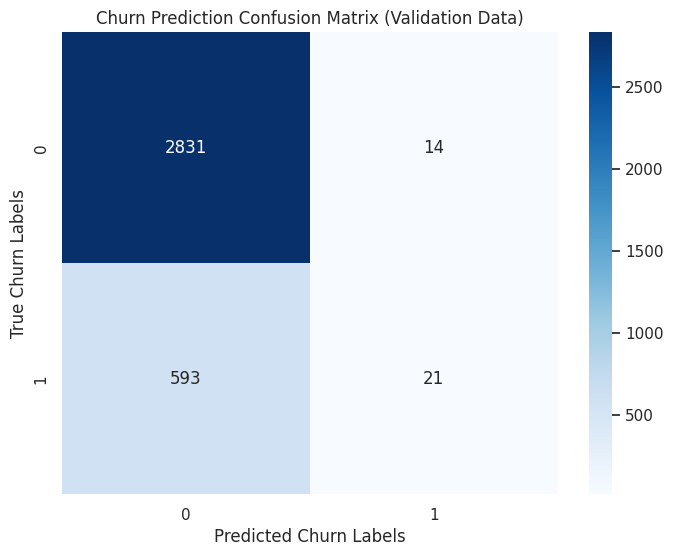

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix for the validation set
churn_cm_val = confusion_matrix(y_val, y_val_pred)

# Create heatmap plot of the confusion matrix
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visualization
ax = plt.subplot()
sns.heatmap(churn_cm_val, annot=True, ax=ax, cmap='Blues', fmt='g')

# Set plot labels and title for clarity
ax.set_xlabel('Predicted Churn Labels')
ax.set_ylabel('True Churn Labels')
ax.set_title('Churn Prediction Confusion Matrix (Validation Data)')

# Show the plot
plt.show()


> Results: The confusion matrix for the validation set visually represents the model's performance in predicting churn, highlighting the counts of true positives, true negatives, false positives, and false negatives.

<hr>

### Assessing the Performance Metrics on the Test Set

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Predict on test set and evaluate performance
y_test_pred = clf.predict(X_test_transformed)

# Calculate evaluation metrics on test data for churn prediction
churn_acc_test = accuracy_score(y_test, y_test_pred)
churn_precision_test = precision_score(y_test, y_test_pred)
churn_recall_test = recall_score(y_test, y_test_pred)
churn_f1_test = f1_score(y_test, y_test_pred)
churn_auc_roc_test = roc_auc_score(y_test, clf.predict_proba(X_test_transformed)[:, 1])

# Print evaluation metrics for churn prediction on the test data
print('\nChurn Prediction Test Set Evaluation Metrics:')
print(f'Accuracy: {churn_acc_test:.6f}')
print(f'Precision: {churn_precision_test:.6f}')
print(f'Recall: {churn_recall_test:.6f}')
print(f'F1 Score: {churn_f1_test:.6f}')
print(f'AUC-ROC Score: {churn_auc_roc_test:.6f}')



Churn Prediction Test Set Evaluation Metrics:
Accuracy: 0.823070
Precision: 0.523810
Recall: 0.035831
F1 Score: 0.067073
AUC-ROC Score: 0.679248


In [ ]:
from sklearn.metrics import classification_report

# Create classification report for churn prediction on test data
churn_test_report = classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn'])

# Print the classification report for the test data
print('\nChurn Prediction Classification Report (Test Data):')
print(churn_test_report)



Churn Prediction Classification Report (Test Data):
              precision    recall  f1-score   support

    No Churn       0.83      0.99      0.90      2845
       Churn       0.52      0.04      0.07       614

    accuracy                           0.82      3459
   macro avg       0.68      0.51      0.48      3459
weighted avg       0.77      0.82      0.75      3459



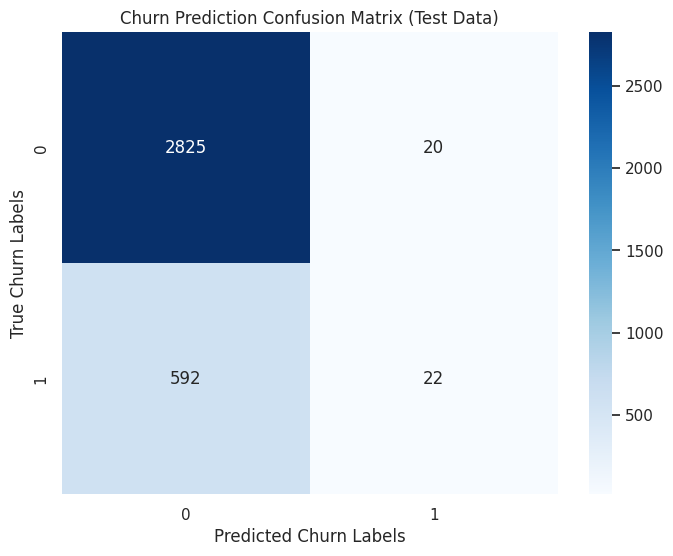

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate confusion matrix for churn prediction on test data
churn_cm_test = confusion_matrix(y_test, y_test_pred)

# Create a heatmap plot of the confusion matrix for the test data
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visualization
ax = plt.subplot()
sns.heatmap(churn_cm_test, annot=True, ax=ax, cmap='Blues', fmt='g')

# Set plot labels and title for the churn confusion matrix
ax.set_xlabel('Predicted Churn Labels')
ax.set_ylabel('True Churn Labels')
ax.set_title('Churn Prediction Confusion Matrix (Test Data)')

# Show the plot
plt.show()


In [ ]:
# Get predicted probabilities for the validation and test sets
y_val_proba = clf.predict_proba(X_val_transformed)[:, 1]  # Probabilities for the positive class (Churn)
y_test_proba = clf.predict_proba(X_test_transformed)[:, 1]  # Probabilities for the positive class (Churn)


In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate AUC-ROC score for validation and test sets
val_auc = roc_auc_score(y_val, y_val_proba)
test_auc = roc_auc_score(y_test, y_test_proba)

# Print the AUC scores for validation and test sets
print(f'Validation AUC-ROC Score: {val_auc:.6f}')
print(f'Test AUC-ROC Score: {test_auc:.6f}')


Validation AUC-ROC Score: 0.683541
Test AUC-ROC Score: 0.679248


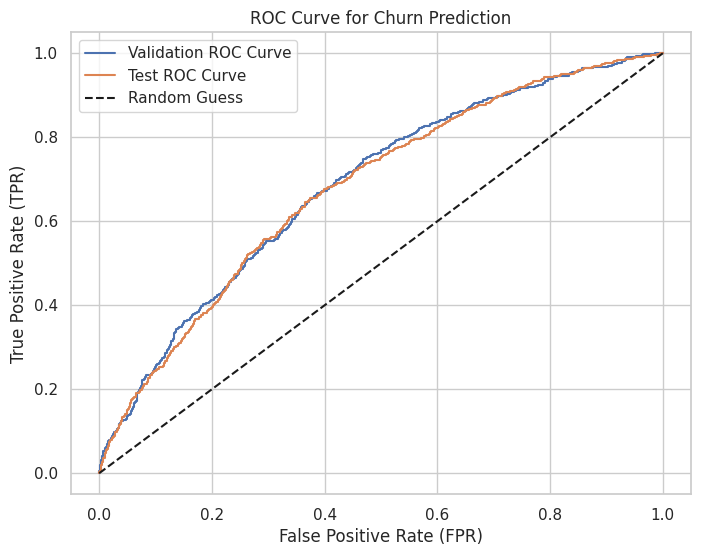

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Generate ROC curves for the validation and test sets
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

# Plot the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, label='Validation ROC Curve')
plt.plot(fpr_test, tpr_test, label='Test ROC Curve')

# Plot the baseline (random guess) for comparison
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Set plot labels and title
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Churn Prediction')
plt.legend(loc='best')

# Show the plot
plt.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=2e817fa5-90a9-46a6-9b23-f777be7d003d' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>